# DynaSD Validation Analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import scipy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from kneed import KneeLocator

import sys
import os
from os.path import join as ospj
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import nibabel as nib
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score
from sklearn.linear_model import LogisticRegression
from utils import cohens_d, delongs_test, load_electrode_localizations
# Load configuration paths and settings
from config import Config
# Extract key paths: raw data, processed data, metadata, figures, and patient IDs
datapath, prodatapath, metapath, figpath, rid_hup = Config.deal(['datapath','prodatapath','metapath','figpath','rid_hup'])

pal = sns.color_palette('Set2')[:2][::-1] + ['grey']

In [3]:
def plot_sig_nsig(sig,nsig,bins=np.linspace(-1,1,20),vbox_int=10):
    # Count data in each bin
    bin_width = bins[1] - bins[0]

    hist_sig, _ = np.histogram(sig, bins=bins)
    hist_not_sig, _ = np.histogram(nsig, bins=bins)

    # Create the blocks
    fig, ax = plt.subplots()

    # Plot each block for not significant
    for i, count in enumerate(hist_not_sig):
        ax.bar(bins[i], count, width=bin_width, color=sns.color_palette('rocket_r')[4], edgecolor='none', label='not significant' if i == 0 else "")

    # Plot each block for significant
    for i, count in enumerate(hist_sig):
        ax.bar(bins[i], count, width=bin_width, color=sns.color_palette('rocket_r')[2], edgecolor='none', bottom=hist_not_sig[i],
            label='significant' if i == 0 else "")
        
    for i in range(0,max(hist_sig+hist_not_sig),vbox_int):
        plt.axhline(i,color='white')
    for i in bins:
        plt.axvline(i + bin_width/2,color='white')
    # Customize plot
    ax.legend()
    plt.tight_layout()
    return fig,ax
    

In [4]:
def get_nparam_stats(data,group,x1,x2,val):
    d1 = data[data[group] == x1][val].to_numpy()
    d2 = data[data[group] == x2][val].to_numpy()
    u,p = sc.stats.mannwhitneyu(d1,d2)
    auc = u/(len(d1)*len(d2))
    return p,u,auc

In [5]:
metadata_df = pd.read_csv(ospj(metapath,'metadata_v7_BIDS.csv'))
metadata_df['patient'] = 'HUP' + metadata_df.patient.astype(int).astype(str).apply(lambda x: x.zfill(3))
metadata_df.drop([col for col in metadata_df.columns if 'Unnamed' in col],axis=1,inplace=True)
metadata_df['notes'] = metadata_df['notes'].fillna('')
metadata_df = metadata_df[(metadata_df['stim'] < 1)]

metadata_df['onset'] = metadata_df['onset'].astype(int).astype(float)

good_val = 1.2
metadata_df['outcome'] = metadata_df.seizure_Engel24m.astype(float)

########################
# outcome_mask = metadata_df.outcome.isna() & (metadata_df.seizure_Engel12m.astype(float) > good_val)
# outcome_mask = metadata_df.seizure_Engel12m.astype(float) > good_val
# metadata_df.loc[outcome_mask,'outcome'] = metadata_df[["seizure_Engel12m"]].astype(float)
########################

# ANDY OUTCOMES
########################
# andy_outcomes = pd.read_csv(ospj(metapath,'patient_cohort_all_atlas_update_mj.csv'))
# metadata_df = metadata_df.merge(andy_outcomes[['Patient','Engel_24_mo']],how='inner',on='Patient')
# metadata_df['outcome'] = metadata_df['Engel_24_mo'].astype(float)
# andy_seizures = pd.read_csv(ospj(metapath,'metadata_for_seizure_spread.csv'))
# print(andy_seizures.Patient[~andy_seizures.Patient.isin(metadata_df.Patient)].unique())
# merged_df = metadata_df.merge(
#     andy_seizures[['Patient', 'Seizure UEO']],
#     how='inner',
#     on='Patient',
#     suffixes=('', '_andy')
# )

# # Find rows where outcome is approximately in Seizure UEO with a tolerance of 360
# mask = np.abs(merged_df['onset'] - merged_df['Seizure UEO']) <= 360
# metadata_df = merged_df[mask].copy()

# # Remove extra column to keep metadata_df columns consistent
# metadata_df.drop(columns=['Seizure UEO'], inplace=True)

#########################
metadata_df.loc[~metadata_df.outcome.isna(),'outcome'] = (metadata_df.loc[~metadata_df.outcome.isna(),'outcome'] <= good_val).astype(float)

treatment_metadata = pd.read_csv(ospj(metapath,'patient_cohort_all_atlas_update_mj.csv'))
metadata_df = metadata_df.merge(treatment_metadata[['Patient','Therapy','Target','Laterality']],on='Patient',how='left')

resection_metadata = pd.read_csv(ospj(metapath,'resection_type_metadata.csv'))
resection_metadata['Patient'] = resection_metadata['HUP Number'].apply(lambda x: 'HUP'+str.zfill(str(x),3) if str(x).isdigit() else x)
resection_metadata.fillna({'Resection lobe:':''},inplace=True)
resection_metadata['ATL'] = resection_metadata['Resection lobe:'].apply(lambda x: 'Anterior Temporal Lobectomy' in x)
metadata_df = metadata_df.merge(resection_metadata[['Patient','ATL']],on='Patient',how='left')
metadata_df.fillna({'ATL':False},inplace=True)
## testing outcome extremes
# middle_mask = (metadata_df.outcome >1.2) & (metadata_df.outcome < 2) & (metadata_df.outcome_val==False)
# middle_mask = metadata_df.outcome_val == False
# metadata_df.loc[middle_mask,'outcome'] = np.nan
##

metadata_df['ieeg_isFocal'] = metadata_df.ieeg_isFocal == 1

def alt_focality(row):
    if row.SOZ_region == 'diffuse':
        alt_focal = 'diffuse'
    else:
        alt_focal = 'focal'
    return alt_focal

metadata_df['alt_focal'] = metadata_df.apply(alt_focality,axis=1)

def all_focality(row):
    if row.SOZ_region == 'diffuse':
        alt_focal = 'diffuse'
    elif row.ieeg_isFocal == 0:
        alt_focal = 'multifocal'
    else:
        alt_focal = 'unifocal'
    return alt_focal

metadata_df['all_focal'] = metadata_df.apply(all_focality,axis=1)

In [6]:
metadata_df[~metadata_df.outcome.isna()].patient.nunique()

93

In [7]:
(metadata_df[metadata_df.ATL & ~metadata_df.seizure_Engel24m.isna()].groupby('patient')['seizure_Engel24m'].median().to_numpy() <=1.1).sum()

np.int64(10)

In [8]:
metadata_df[metadata_df.ATL & ~metadata_df.seizure_Engel24m.isna()].patient.nunique()
# metadata_df[((metadata_df.Therapy == 'Resection') | (metadata_df.Therapy == 'Ablation')) & ~metadata_df.seizure_Engel24m.isna()].patient.nunique()

26

In [9]:
metadata_df[(metadata_df.Therapy == 'Resection') & (metadata_df.Target.apply(lambda x: x in ['Temporal','MTL'])) & ~metadata_df.seizure_Engel24m.isna()].patient.nunique()

34

In [10]:
pt_metadata_df = metadata_df.groupby('patient')[['record_id','outcome','SOZ_region','SOZ_lateralization','fiveSenseScore','ieeg_isFocal','Semiology','alt_focal','all_focal']].apply(lambda x: x.iloc[0,:])

In [11]:
# thresh_str = 'pretrained_manuscript'
thresh_str = 'pretrained_median'
# mdl_str = 'GIN_seq-12_forecast-1'
# mdl_str = 'LiNDDA_seq-5_forecast-4'
mdl_str = 'LiNDDA_seq-3_forecast-2'
# mdl_str = 'WVNT_seq-None_forecast-None'
similarity_df = pd.read_pickle(ospj(prodatapath,f"patient_similarity_analysis_mdl-{mdl_str}_thresh-{thresh_str}.pkl"))
summary_df = pd.read_pickle(ospj(prodatapath,f"seizure_spread_summary_mdl-{mdl_str}_thresh-{thresh_str}.pkl"))

In [12]:
similarity_df

,patient,avg_dice_similarity_ch,median_dice_similarity_ch,max_dice_similarity_ch,var_dice_similarity_ch,avg_ndd_pearson_ch,avg_ndd_spearman_ch,avg_spearman_ch,median_spearman_ch,max_spearman_ch,...,median_dice_similarity_region,max_dice_similarity_region,var_dice_similarity_region,avg_ndd_pearson_region,avg_ndd_spearman_region,avg_spearman_region,median_spearman_region,max_spearman_region,var_spearman_region,percent_seizing_region
0,HUP065,0.222222,0.000000,0.666667,0.098765,0.557831,0.560637,0.727393,0.737564,0.769086,...,0.000000,1.000000,0.222222,0.695101,0.762637,0.828021,0.810377,0.922116,0.005003,"[0.06666666666666667, 0.06666666666666667, 0.0..."
1,HUP068,0.875828,0.886752,0.948454,0.002605,-0.004415,0.012718,0.743553,0.767489,0.876508,...,0.888889,1.000000,0.021223,0.075345,0.087895,0.609206,0.767592,0.994194,0.099583,"[0.6842105263157895, 0.6842105263157895, 0.684..."
2,HUP070,0.652666,0.632500,0.941176,0.032822,0.517591,0.245844,0.650922,0.686279,0.949112,...,0.909091,1.000000,0.008435,NaN,NaN,0.576723,0.628517,1.000000,0.074085,"[0.7692307692307693, 0.7692307692307693, 0.769..."
3,HUP073,0.083333,0.000000,0.500000,0.034722,0.137847,0.157744,0.076094,0.039328,0.403863,...,0.920363,0.969697,0.001081,0.125836,0.177696,0.505493,0.503599,0.727607,0.023676,"[0.8611111111111112, 0.8611111111111112, 0.861..."
4,HUP074,0.702701,0.781036,0.857143,0.021461,0.261767,0.270778,0.678258,0.671622,0.799459,...,0.472727,1.000000,0.063453,0.409872,0.316835,0.349167,0.526192,0.891998,0.136399,"[0.09523809523809523, 0.09523809523809523, 0.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,HUP295,0.530782,0.535897,0.782609,0.030033,0.158097,0.135540,0.636971,0.716587,0.850102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
158,HUP298,0.375703,0.333333,0.800000,0.040047,0.294464,0.303679,0.733700,0.761837,0.778777,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
159,HUP299,0.676518,0.711982,0.974359,0.028061,0.462372,0.420678,0.663925,0.675911,0.904620,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
160,HUP301,0.725566,0.811111,0.957627,0.037343,0.279996,0.252831,0.596949,0.598743,0.882209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [13]:
summary_df_wmeta = summary_df.merge(metadata_df,how='inner',on=['patient','onset'])
summary_df_wmeta.dropna(subset= ['ieeg_isFocal'],axis=0,how='any')
# summary_df_wmeta.to_csv(ospj(prodatapath,'seizure_level_annotations_wmeta.csv'))
# summary_df_wmeta.to_pickle(ospj(prodatapath,'seizure_level_annotations_wmeta.pkl'))
similarity_df_wmeta = similarity_df.merge(pt_metadata_df,how='inner',on='patient')
similarity_df_wmeta = similarity_df_wmeta.dropna(subset= ['ieeg_isFocal','avg_dice_similarity_ch','avg_spearman_ch'],axis=0,how='any')

In [14]:
def get_total_chs(group):
    all_chs = set()
    for _,row in group.iterrows():
        all_chs.update(row.all_channels)
    return len(all_chs)
total_chs = summary_df.groupby('patient').apply(get_total_chs).reset_index()
total_chs.columns = ['patient','total_chs']

In [15]:
similarity_df_wmeta = similarity_df_wmeta.merge(total_chs,on='patient')

In [16]:
print(len(similarity_df_wmeta.patient.unique()),len(summary_df_wmeta))

162 2017


In [17]:
print(summary_df_wmeta.patient.nunique())
np.sort(summary_df_wmeta.patient.unique())

176


array(['HUP064', 'HUP065', 'HUP068', 'HUP070', 'HUP072', 'HUP073',
       'HUP074', 'HUP075', 'HUP078', 'HUP080', 'HUP081', 'HUP082',
       'HUP083', 'HUP084', 'HUP086', 'HUP087', 'HUP088', 'HUP089',
       'HUP093', 'HUP094', 'HUP096', 'HUP097', 'HUP098', 'HUP099',
       'HUP100', 'HUP101', 'HUP102', 'HUP105', 'HUP106', 'HUP107',
       'HUP108', 'HUP110', 'HUP111', 'HUP112', 'HUP113', 'HUP114',
       'HUP116', 'HUP117', 'HUP118', 'HUP119', 'HUP120', 'HUP121',
       'HUP123', 'HUP126', 'HUP127', 'HUP128', 'HUP129', 'HUP130',
       'HUP131', 'HUP132', 'HUP133', 'HUP134', 'HUP135', 'HUP136',
       'HUP137', 'HUP138', 'HUP139', 'HUP141', 'HUP142', 'HUP143',
       'HUP144', 'HUP145', 'HUP146', 'HUP147', 'HUP148', 'HUP149',
       'HUP150', 'HUP151', 'HUP152', 'HUP153', 'HUP154', 'HUP155',
       'HUP156', 'HUP157', 'HUP158', 'HUP159', 'HUP160', 'HUP161',
       'HUP162', 'HUP163', 'HUP164', 'HUP165', 'HUP166', 'HUP167',
       'HUP168', 'HUP169', 'HUP170', 'HUP171', 'HUP172', 'HUP1

In [18]:
all_outcome_chs = []
for _,row in summary_df_wmeta.iterrows():
    if np.isnan(row.outcome):
        continue

    electrode_df = load_electrode_localizations(row.patient,prodatapath,keep_white_matter=True,return_df=True)
    if electrode_df is None:
        continue
    
    patient = row.patient
    onset = row.onset
    outcome = row.outcome
    therapy = row.Therapy
    target = row.Target
    laterality = row.Laterality
    atl = row.ATL
    engel = row.seizure_Engel24m
    n_channels = len(electrode_df)
    n_rois = electrode_df[electrode_df.roiNum.notna()].roiNum.nunique()
    # print(row.patient,row.onset,row.max_time)
    for ch,time in row.channel_spread_time.items():
        time = time #if ~np.isnan(time) else row.max_time
        ch_dict = {}
        ch_unique = ch.split('-')[0]
        if ch_unique not in electrode_df.labels.values:
            continue
        ch_idx = electrode_df[electrode_df.labels == ch_unique].index.values[0]
        ch_info = electrode_df.loc[ch_idx,['labels','mm_x','mm_y','mm_z','roi','roiNum']]
        ch_dict = {key:ch_info[key] for key in ch_info.keys()}
        ch_dict['patient'] = patient
        ch_dict['onset'] = onset
        ch_dict['outcome'] = outcome
        ch_dict['engel'] = engel
        ch_dict['therapy'] = therapy
        ch_dict['target'] = target
        ch_dict['laterality'] = laterality
        ch_dict['atl'] = atl
        ch_dict['n_channels'] = n_channels
        ch_dict['n_rois'] = n_rois
        ch_dict['channel'] = ch
        ch_dict['time'] = time
        all_outcome_chs.append(ch_dict)
all_outcome_df = pd.DataFrame(all_outcome_chs)
all_outcome_df.to_csv(ospj(prodatapath,f'seizure_spread_outcome_mdl-{mdl_str}_thresh-{thresh_str}.csv'),index=False)

## Spread analyses

### Channel baseline

MannwhitneyuResult(statistic=np.float64(2065.5), pvalue=np.float64(0.00036615762610537125))

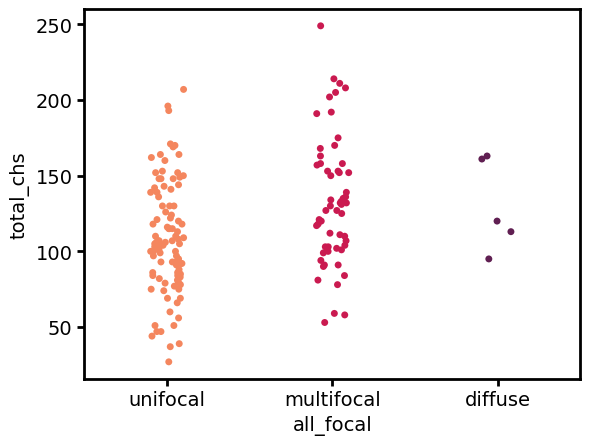

In [19]:
sns.stripplot(similarity_df_wmeta,x='all_focal',hue='all_focal',y='total_chs',palette='rocket_r')
# sns.violinplot(similarity_df_wmeta,x='ieeg_isFocal',hue='ieeg_isFocal',y='total_chs',palette='rocket',fill=False,inner='quart',width=.5)
sc.stats.mannwhitneyu(similarity_df_wmeta[similarity_df_wmeta.ieeg_isFocal == 1].total_chs,
                     similarity_df_wmeta[similarity_df_wmeta.ieeg_isFocal == 0].total_chs)

In [20]:
# Define the time variable
time_points = np.arange(0, 60.5, 0.5)
key = 'fraction_seizing_ch'
# Expand DataFrame
expanded_data = []
# summary_df_wmeta['notes'].apply(lambda x: 'nina' not in x.lower()) & summary_df_wmeta['source'].apply(lambda x: 'nina' not in x.lower())
for _, row in summary_df_wmeta.iterrows():
    if row[key] is None:
        continue
    # if (row.offset - row.onset) < 15:
    #     continue
    for t, value in zip(time_points, row[key]):
        if value is None:
            continue
        expanded_data.append({
            "time": t,
            "percent_seizing": value*100,
            "patient": row["patient"],
            "isFocal": row["ieeg_isFocal"],
            "outcome": row["outcome"],
            "Semiology": row["Semiology"],
            "onset": row['onset'],
            "Focality": row['alt_focal'],
            "laterality": row['SOZ_lateralization'] == 'bilateral'
        })

# Create the expanded DataFrame
long_df = pd.DataFrame(expanded_data)

In [21]:
sorted(summary_df_wmeta[summary_df_wmeta.Semiology == 'FAS'].reset_index().loc[0,'onset_channels'])

['LFP01-LFP02',
 'LG11-LG12',
 'LG12-LG13',
 'LG13-LG14',
 'LG14-LG15',
 'LG15-LG16',
 'LG18-LG19',
 'LG19-LG20',
 'LG20-LG21',
 'LG21-LG22',
 'LG22-LG23',
 'LG23-LG24',
 'LG26-LG27',
 'LG28-LG29',
 'LG29-LG30',
 'LG30-LG31',
 'LG31-LG32',
 'LG32-LG33',
 'LG35-LG36',
 'LG36-LG37',
 'LG37-LG38',
 'LG38-LG39']

### Semiology

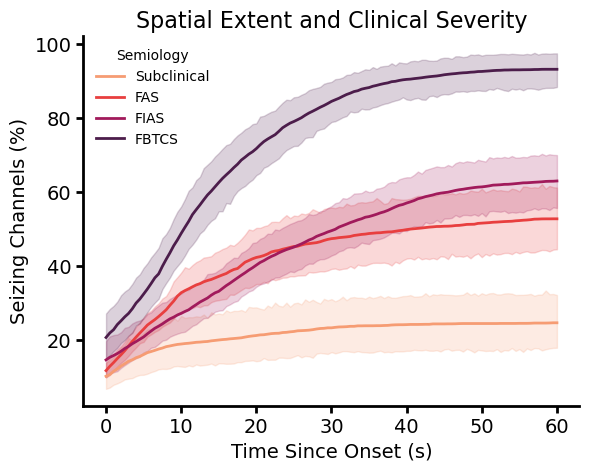

In [22]:
# Example grouped line plot
sns.lineplot(
    data=long_df,
    x="time",
    y="percent_seizing",
    hue="Semiology",
    legend=True,
    palette = 'rocket_r',
    hue_order=['Subclinical','FAS','FIAS','FBTCS']
)
plt.title("Spatial Extent and Clinical Severity")
plt.ylabel('Seizing Channels (%)')
plt.xlabel("Time Since Onset (s)")
sns.despine()

In [23]:
# from sklearn.ensemble import GradientBoostingClassifier
# all_preds = []
# mdl_df = long_df[long_df.time==20]
# for pt in mdl_df.onset.unique():
#     X_train = mdl_df[mdl_df.onset != pt]
#     X_test = mdl_df[mdl_df.onset == pt]
#     y_train = X_train[['Semiology']] == 'FBTCS'
#     y_test = X_test[['Semiology']] == 'FBTCS'
#     clf = GradientBoostingClassifier()
#     clf.fit(X_train[['percent_seizing']],y_train.to_numpy().ravel())
#     y_pred = clf.predict_proba(X_test[['percent_seizing']])
#     all_preds.append([y_test.to_numpy()[0][0],y_pred[0][1]])
# all_preds = np.array(all_preds)

In [24]:
# print(roc_auc_score(all_preds[:,0],all_preds[:,1]))
# print(sum((all_preds[:,1] > 0.5) == all_preds[:,0])/len(all_preds))

### Outcome

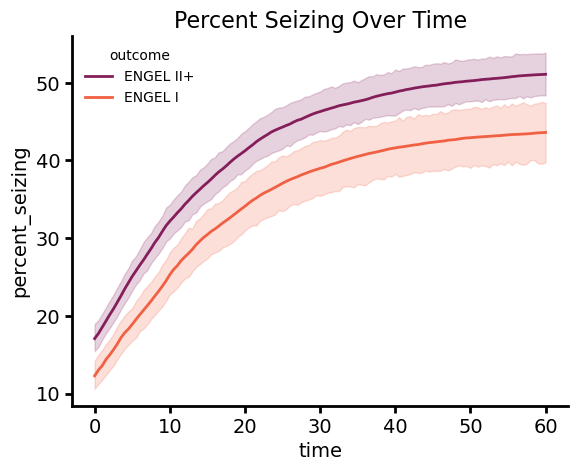

In [25]:

long_df_outcome = long_df[(long_df.Focality != 'diffuse') & (~long_df.outcome.isna())]
long_df_outcome['outcome'] = long_df_outcome['outcome'].map({0.0:'ENGEL II+',1.0:'ENGEL I'})
sns.lineplot(
    data=long_df_outcome,
    x="time",
    y="percent_seizing",
    hue="outcome",
    hue_order=['ENGEL II+','ENGEL I'],
    legend=True,
    palette = 'rocket',
    # hue_order=['false','true']
)
plt.title("Percent Seizing Over Time")

sns.despine()
plt.show()

In [26]:
def random_patient_model(lme_data,group_var,value):
    lme_data = lme_data[
        lme_data[group_var].notnull() &
        lme_data[value].notnull() &
        lme_data['patient'].notnull()
    ]

    # Ensure patient is treated as a categorical
    lme_data['patient'] = lme_data['patient'].astype(str)

    # Fit the LME model: phi_diff ~ 1 + (1|patient)
    md = smf.mixedlm(
        f"{value} ~ {group_var}",
        lme_data,
        groups=lme_data["patient"]
    )
    lme_model = md.fit()
    p_value_idx = [group_var in x for x in lme_model.pvalues.index]
    return lme_model.pvalues[p_value_idx].values[0]

In [27]:
print(long_df_outcome.patient.nunique())
outcome_effect = [cohens_d(long_df_outcome[(long_df_outcome.outcome == 'ENGEL II+') & (long_df_outcome.time == t)].percent_seizing,
                           long_df_outcome[(long_df_outcome.outcome == 'ENGEL I') & (long_df_outcome.time == t)].percent_seizing)
                           for t in time_points]
                           
# outcome_sig = [sc.stats.ttest_ind(long_df_outcome[(long_df_outcome.outcome == 'ENGEL IC+') & (long_df_outcome.time == t)].percent_seizing,
#                            long_df_outcome[(long_df_outcome.outcome == 'ENGEL IAB') & (long_df_outcome.time == t)].percent_seizing)[1]
#                            for t in time_points]
outcome_sig = [random_patient_model(long_df_outcome[(long_df_outcome.time == t)],'outcome','percent_seizing') for t in time_points]

88


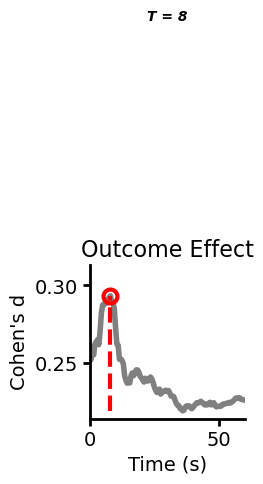

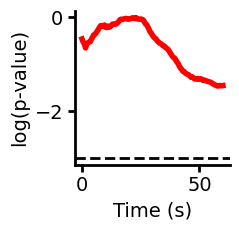

In [28]:
plt.figure(figsize=(2,2))
plt.plot(time_points,outcome_effect,color='gray',linewidth=4)
plt.xlim([0,60])
# plt.axvspan(0,4,color='red',alpha=.2)
# plt.axvline(4,color='red')
plt.plot(time_points[np.argmax(outcome_effect)],outcome_effect[np.argmax(outcome_effect)],'o',color='red',markersize=10,fillstyle='none',markeredgewidth=3)
plt.plot([time_points[np.argmax(outcome_effect)]]*2,[np.min(outcome_effect),outcome_effect[np.argmax(outcome_effect)]],'--',color='red',linewidth=3)
plt.text(30,0.47,f'T = {np.round(time_points[np.argmax(outcome_effect)],1).astype(int)}',fontsize=10,ha='center',fontweight='bold',fontstyle='italic',color='black')
plt.ylabel('Cohen\'s d')
plt.xlabel('Time (s)')
plt.title('Outcome Effect')
plt.ylim([np.min(outcome_effect)-0.005,np.max(outcome_effect)+0.02])
sns.despine()

plt.figure(figsize=(2,2))
plt.plot(time_points,np.log(outcome_sig),linestyle='-',color='red',linewidth=4)
plt.axhline(np.log(0.05),linestyle='--',color='black',linewidth=2)
plt.ylabel('log(p-value)')
plt.xlabel('Time (s)')
sns.despine()

### Focality

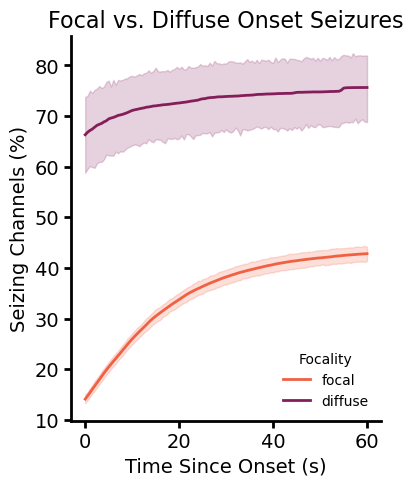

In [42]:
_,ax = plt.subplots(figsize=(4,5))
sns.lineplot(
    data=long_df,
    x="time",
    y="percent_seizing",
    hue="Focality",
    legend=True,
    palette = 'rocket_r',
    # style='laterality'
    # hue_order=['false','true']
)
plt.title("Focal vs. Diffuse Onset Seizures")
plt.ylabel('Seizing Channels (%)')
plt.xlabel('Time Since Onset (s)')
sns.despine()
plt.savefig(ospj(figpath,'focality_seizure_spread.pdf'),bbox_inches='tight')

In [43]:
from functools import reduce
mdl_df = summary_df_wmeta.groupby('patient').agg({
    'alt_focal':'max',
    'ieeg_isFocal':'max',
    'all_focal':'max',
    'fiveSenseScore':'mean',
    'spread_channels':lambda x: len(reduce(np.union1d,x)),
    'onset_channels':lambda x: len(reduce(np.union1d,x)),
    'all_channels':lambda x: len(reduce(np.union1d,x))}).reset_index()

In [44]:
mdl_df['percent_seizing'] = mdl_df['onset_channels']/mdl_df['all_channels']*100
mdl_df['Focality'] = mdl_df['all_focal']
mdl_df = mdl_df[mdl_df['Focality'] != 'multifocal']
mdl_df = mdl_df.dropna(subset=['percent_seizing', 'fiveSenseScore'])

# Print number of patients in each group using existing mdl_df
print("Number of patients by Focality:")
print(mdl_df['Focality'].value_counts())

print("\nPercent seizing (median [25th, 75th percentile]) by group:")
for group in ['unifocal', 'diffuse']:
    vals = mdl_df.loc[mdl_df['Focality'] == group, 'percent_seizing']
    if len(vals) > 0:
        median = np.median(vals)
        q1 = np.percentile(vals, 25)
        q3 = np.percentile(vals, 75)
        print(f"{group.title()}: {median:.2f} [{q1:.2f}, {q3:.2f}]")
    else:
        print(f"{group.title()}: No data")

# Get non-parametric stats for percent_seizing by Focality
from scipy.stats import mannwhitneyu
vals1 = mdl_df.loc[mdl_df['Focality'] == 'unifocal', 'percent_seizing']
vals2 = mdl_df.loc[mdl_df['Focality'] == 'diffuse', 'percent_seizing']
if len(vals1) > 0 and len(vals2) > 0:
    stat, pval = mannwhitneyu(vals1, vals2, alternative='two-sided')
    print(f"\nMann-Whitney U test between unifocal and diffuse percent_seizing:")
    print(f"U = {stat:.2f}, p = {pval:.3g}")
else:
    print('\nNot enough data to compute Mann-Whitney U test.')

Number of patients by Focality:
Focality
unifocal    88
diffuse      6
Name: count, dtype: int64

Percent seizing (median [25th, 75th percentile]) by group:
Unifocal: 32.86 [14.39, 57.73]
Diffuse: 96.06 [70.37, 97.74]

Mann-Whitney U test between unifocal and diffuse percent_seizing:
U = 58.50, p = 0.00152


In [45]:
# from sklearn.tree import DecisionTreeClassifier
all_preds = []
all_predscontrol = []
all_preds_combine = []
all_preds = np.zeros((mdl_df.patient.nunique(),3,2))
for i_pt,pt in enumerate(mdl_df.patient.unique()):
    X_train = mdl_df[mdl_df.patient != pt]
    X_test = mdl_df[mdl_df.patient == pt]
    y_train = X_train[['Focality']] == 'unifocal'
    y_test = X_test[['Focality']] == 'unifocal'
    for i,feat in enumerate([['percent_seizing'],['fiveSenseScore'],['percent_seizing','fiveSenseScore']]):
        clf = LogisticRegression(
            penalty=None,
            class_weight='balanced'
            )
        # clf.fit(X_train[['percent_seizing']],y_train.to_numpy().ravel())
        # y_pred = clf.predict_proba(X_test[['percent_seizing']])
        clf.fit(X_train[feat],y_train.to_numpy().ravel())
        y_pred = clf.predict_proba(X_test[feat])
        all_preds[i_pt,i,:] = [y_test.to_numpy()[0][0],y_pred[0][1]]
        # all_preds.append()
# all_preds = np.array(all_preds)
# roc_auc_score(all_preds[:,0],all_preds[:,1])

{'auc1': np.float64(0.8636363636363636), 'auc2': np.float64(0.5378787878787878), 'auc_diff': np.float64(0.3257575757575758), 'z_score': np.float64(1.9938000463386267), 'p_value': np.float64(0.0461739105213721), 'se': np.float64(0.16338527845647827), 'var1': np.float64(0.0025556637429678176), 'var2': np.float64(0.018104602714712432), 'covariance': np.float64(-0.003017241379310343)}


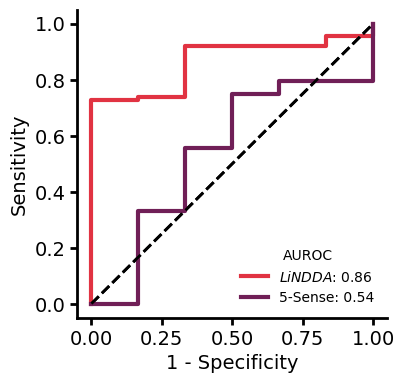

In [46]:
label_strs = ['$LiNDDA$','5-Sense']#,'NDD+5']
colors = np.array(sns.color_palette('rocket_r',as_cmap=False))[[2,4,]]
fig,ax = plt.subplots(figsize=(4,4))
print(delongs_test(all_preds[:,0,0],all_preds[:,0,1],all_preds[:,1,1]))
for i in range(2):
    plot_preds = np.squeeze(all_preds[:,i,:])
    fpr,tpr,thresholds = roc_curve(plot_preds[:,0],plot_preds[:,1])
    # plt.figure()
    plt.plot(fpr,tpr,c=colors[i],linewidth=3, label=label_strs[i]+f': {np.round(roc_auc_score(plot_preds[:,0],plot_preds[:,1]),2)}')
    plt.plot([0,1],[0,1],c='black',linewidth=2,linestyle='--')
    sns.despine()
    plt.ylabel('Sensitivity')
    plt.xlabel('1 - Specificity')
    plt.legend(title='AUROC')
    # plt.text(0.7,.2,f'AUROC: {np.round(roc_auc_score(plot_preds[:,0],plot_preds[:,1]),2)}',fontsize=16)
    plt.savefig(ospj(figpath,'diffuse_detection_roc.pdf'),bbox_inches='tight')

In [47]:
# plt.figure(figsize=(4,6))
# x = long_df[(long_df.time == 10)].groupby('patient',as_index=False).agg({'Focality':'max','percent_seizing':'max','Focality':'max'})
# # sns.stripplot(x,x='Focality',y='percent_seizing',hue='Focality',palette='rocket_r')#,width=0.2,gap=-3)
# sns.stripplot(long_df[(long_df.time == 10)],x='Focality',y='percent_seizing',hue='Focality',palette='rocket_r',
# # width=0.2,gap=-3
# )
# plt.show()

# plt.figure(figsize=(4,6))
# sns.pointplot(x,x='Focality',y='percent_seizing',hue='Focality',palette='rocket_r')
# sns.stripplot(x,x='Focality',y='percent_seizing',color='gray',alpha=0.2)
# sns.despine()

# print(sc.stats.ttest_ind(long_df[(long_df.time <= 1)&(long_df.Focality == 'focal')].percent_seizing,
#                       long_df[(long_df.time <= 1)&(long_df.Focality == 'diffuse')].percent_seizing))
# # long_df[(long_df.time <= 0)&(long_df.isFocal == False)].percent_seizing.mean() - long_df[(long_df.time <= 0)&(long_df.isFocal == True)].percent_seizing.mean()
# print(cohens_d(long_df[(long_df.time <= 1)&(long_df.Focality == 'diffuse')].percent_seizing,
#                       long_df[(long_df.time <= 1)&(long_df.Focality == 'focal')].percent_seizing))
# print(long_df[(long_df.time <= 1)&(long_df.Focality == 'diffuse')].percent_seizing.median(),
#       long_df[(long_df.time <= 1)&(long_df.Focality == 'focal')].percent_seizing.median())
# sns.despine()

## Seizure Similarity

In [80]:
plot_similarity_df_wmeta = similarity_df_wmeta[similarity_df_wmeta.all_focal != 'diffuse']
# plot_similarity_df_wmeta = similarity_df_wmeta.copy()
# Print descriptive stats about the number of unique patients in each 'all_focal' group
n_patients_per_group = plot_similarity_df_wmeta.groupby('all_focal')['patient'].nunique()
print("Number of unique patients per all_focal group:")
print(n_patients_per_group)

Number of unique patients per all_focal group:
all_focal
multifocal     57
unifocal      100
Name: patient, dtype: int64


### Onset Similarity

p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

unifocal vs. multifocal: t-test independent samples with Benjamini-Hochberg correction, P_val:4.219e-03 t=2.904e+00
(np.float64(0.0028954932771523803), np.float64(3666.5), np.float64(0.6432456140350877))
0.5563152762649616
0.4194083542510877


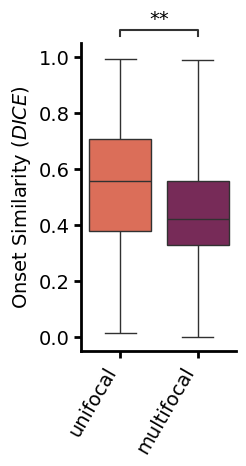

In [81]:
plt.figure(figsize=(2,4))
plt.xticks(rotation=60,ha='right')
ax = sns.boxplot(plot_similarity_df_wmeta,x='all_focal',y='avg_dice_similarity_ch',hue='all_focal',palette='rocket_r',
whis=100,width=0.2,gap=-3,
)
sns.despine()
annotator = Annotator(ax,[('unifocal','multifocal')],data=plot_similarity_df_wmeta,order=['unifocal','multifocal'],x='all_focal',y='avg_dice_similarity_ch')
annotator.configure(test='t-test_ind',
        comparisons_correction="Benjamini-Hochberg",
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
annotator.apply_and_annotate()
u,p = sc.stats.ttest_ind(similarity_df_wmeta.avg_dice_similarity_ch[similarity_df_wmeta.all_focal == 'unifocal'],
                      similarity_df_wmeta.avg_dice_similarity_ch[similarity_df_wmeta.all_focal == 'multifocal'])
            
plt.ylabel('Onset Similarity ($DICE$)')
plt.xlabel('')
plt.ylim([-.05,1.05])
plt.savefig(ospj(figpath,'onset_similarity.pdf'),bbox_inches='tight')

print(get_nparam_stats(similarity_df_wmeta,'all_focal','unifocal','multifocal','avg_dice_similarity_ch'))
print(similarity_df_wmeta.avg_dice_similarity_ch[similarity_df_wmeta.all_focal == 'unifocal'].median())
print(similarity_df_wmeta.avg_dice_similarity_ch[similarity_df_wmeta.all_focal == 'multifocal'].median())

In [82]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import average_precision_score
clf = LogisticRegressionCV(refit=True)
mdl_similarity_df = plot_similarity_df_wmeta.dropna(subset= ['avg_dice_similarity_ch','fiveSenseScore'])
X = mdl_similarity_df[['avg_dice_similarity_ch','fiveSenseScore']]
y = mdl_similarity_df.all_focal == 'unifocal'
clf.fit(X,y)
clf.score(X,y)
preds = clf.predict_proba(X)
print(average_precision_score(y,clf.predict(X)))
# print(clf.predict())

0.6982758620689655


### Spread similarity

p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

unifocal vs. multifocal: t-test independent samples with Benjamini-Hochberg correction, P_val:9.731e-04 t=3.363e+00
0.5818071726414115
0.4692345635353569
(np.float64(0.0004610325840047739), np.float64(3810.0), np.float64(0.6684210526315789))


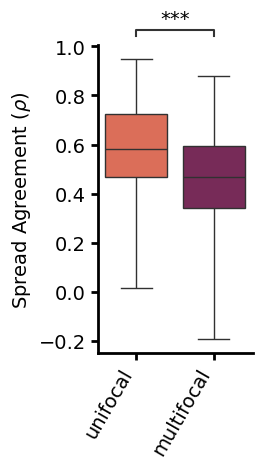

In [83]:
plt.figure(figsize=(2,4))
ax = sns.boxplot(plot_similarity_df_wmeta,x='all_focal',y='avg_spearman_ch',hue='all_focal',palette='rocket_r',whis=100,width=0.2,gap=-3)
sns.despine()
plt.xticks(rotation = 60, ha='right')
plt.xlabel('')
# plt.ylim([-.1,1.05])
plt.ylabel('Spread Agreement ($\\rho$)')
annotator = Annotator(ax,[('unifocal','multifocal')],data=plot_similarity_df_wmeta,order=['unifocal','multifocal'],x='all_focal',y='avg_spearman_ch')
annotator.configure(test='t-test_ind',
        comparisons_correction="Benjamini-Hochberg",
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
annotator.apply_and_annotate()
plt.savefig(ospj(figpath,'spread_similarity.pdf'),bbox_inches='tight')
print(similarity_df_wmeta.avg_spearman_ch[similarity_df_wmeta.all_focal == 'unifocal'].median())
print(similarity_df_wmeta.avg_spearman_ch[similarity_df_wmeta.all_focal == 'multifocal'].median())
print(get_nparam_stats(similarity_df_wmeta,'all_focal','unifocal','multifocal','avg_spearman_ch'))

In [84]:
all_preds = []
all_predscontrol = []
all_preds_combine = []
all_preds = np.zeros((plot_similarity_df_wmeta.patient.nunique(),3,2))
for i_pt,pt in enumerate(mdl_similarity_df.patient.unique()):
    X_train = mdl_similarity_df[mdl_similarity_df.patient != pt]
    X_test = mdl_similarity_df[mdl_similarity_df.patient == pt]
    y_train = X_train[['all_focal']] == 'unifocal'
    y_test = X_test[['all_focal']] == 'unifocal'
    for i,feat in enumerate([['avg_spearman_ch'],['fiveSenseScore'],['avg_spearman_ch','fiveSenseScore']]):
        clf = LogisticRegression(
            penalty=None,
            class_weight='balanced'
            )
        # clf.fit(X_train[['percent_seizing']],y_train.to_numpy().ravel())
        # y_pred = clf.predict_proba(X_test[['percent_seizing']])
        clf.fit(X_train[feat],y_train.to_numpy().ravel())
        y_pred = clf.predict_proba(X_test[feat])
        all_preds[i_pt,i,:] = [y_test.to_numpy()[0][0],y_pred[0][1]]

{'auc1': np.float64(0.8771929824561404), 'auc2': np.float64(0.8321962313190382), 'auc_diff': np.float64(0.04499675113710222), 'z_score': np.float64(1.2212416652538727), 'p_value': np.float64(0.22199453304384242), 'se': np.float64(0.036845083505849974), 'var1': np.float64(0.0007494794923357939), 'var2': np.float64(0.0011155051594785661), 'covariance': np.float64(0.00025371223663065107)}


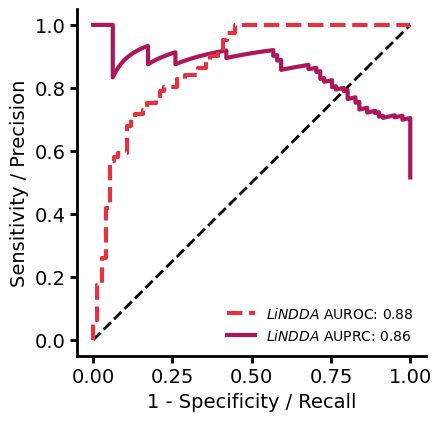

In [88]:
from utils import delongs_test
from sklearn.metrics import precision_recall_curve, average_precision_score

label_strs = ['$LiNDDA$', '5-Sense']
colors = np.array(sns.color_palette('rocket_r', as_cmap=False))[[2, 3, 4]]
fig, ax = plt.subplots(figsize=(4.5, 4.5))
print(delongs_test(all_preds[:, 0, 0], all_preds[:, 0, 1], all_preds[:, 1, 1]))

for i in range(1):
    plot_preds = np.squeeze(all_preds[:, i, :])
    # ROC
    fpr, tpr, thresholds = roc_curve(plot_preds[:, 0], plot_preds[:, 1])
    auroc = roc_auc_score(plot_preds[:, 0], plot_preds[:, 1])
    roc_label = f"{label_strs[i]} AUROC: {auroc:.2f}"

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(plot_preds[:, 0], plot_preds[:, 1])
    auprc = average_precision_score(plot_preds[:, 0], plot_preds[:, 1])
    pr_label = f"{label_strs[i]} AUPRC: {auprc:.2f}"
    
    plt.plot(fpr, tpr, c=colors[i], linestyle='--',linewidth=3, label=roc_label,zorder=2)
    plt.plot(recall, precision, c=colors[1], linestyle='-', linewidth=3, label=pr_label,zorder=1)
    plt.plot([0, 1], [0, 1], c='black', linewidth=2, linestyle='--',zorder=0)

    sns.despine()
    plt.ylabel('Sensitivity / Precision')
    plt.xlabel('1 - Specificity / Recall')
    plt.legend(title='')
    plt.savefig(ospj(figpath, 'multifocal_detection_roc_prc.pdf'), bbox_inches='tight')

{'auc1': np.float64(0.8771929824561404), 'auc2': np.float64(0.8321962313190382), 'auc_diff': np.float64(0.04499675113710222), 'z_score': np.float64(1.2212416652538727), 'p_value': np.float64(0.22199453304384242), 'se': np.float64(0.036845083505849974), 'var1': np.float64(0.0007494794923357939), 'var2': np.float64(0.0011155051594785661), 'covariance': np.float64(0.00025371223663065107)}


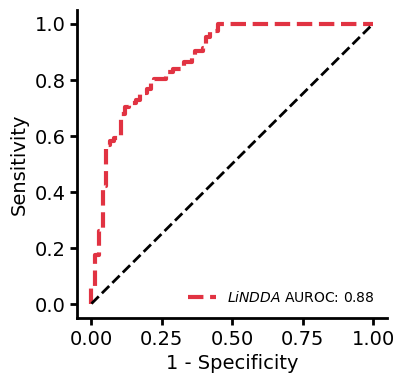

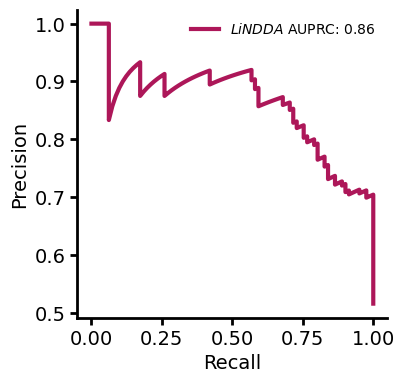

In [87]:
from utils import delongs_test
from sklearn.metrics import precision_recall_curve, average_precision_score

label_strs = ['$LiNDDA$', '5-Sense']
colors = np.array(sns.color_palette('rocket_r', as_cmap=False))[[2, 3, 4]]
print(delongs_test(all_preds[:, 0, 0], all_preds[:, 0, 1], all_preds[:, 1, 1]))

for i in range(1):
    plot_preds = np.squeeze(all_preds[:, i, :])
    # ROC
    fpr, tpr, thresholds = roc_curve(plot_preds[:, 0], plot_preds[:, 1])
    auroc = roc_auc_score(plot_preds[:, 0], plot_preds[:, 1])
    roc_label = f"{label_strs[i]} AUROC: {auroc:.2f}"

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(plot_preds[:, 0], plot_preds[:, 1])
    auprc = average_precision_score(plot_preds[:, 0], plot_preds[:, 1])
    pr_label = f"{label_strs[i]} AUPRC: {auprc:.2f}"

    # Combined plot (ROC+PRC), as before
    fig, ax = plt.subplots(figsize=(4, 4))
    plt.plot(fpr, tpr, c=colors[i], linestyle='--', linewidth=3, label=roc_label, zorder=2)
    plt.plot(recall, precision, c=colors[1], linestyle='-', linewidth=3, label=pr_label, zorder=1)
    plt.plot([0, 1], [0, 1], c='black', linewidth=2, linestyle='--', zorder=0)
    sns.despine()
    plt.ylabel('Sensitivity / Precision')
    plt.xlabel('1 - Specificity / Recall')
    plt.legend(title='')
    plt.savefig(ospj(figpath, 'multifocal_detection_roc_prc.pdf'), bbox_inches='tight')
    plt.close()

    # Save ROC curve alone
    fig_roc, ax_roc = plt.subplots(figsize=(4, 4))
    ax_roc.plot(fpr, tpr, c=colors[i], linestyle='--', linewidth=3, label=roc_label)
    ax_roc.plot([0, 1], [0, 1], c='black', linewidth=2, linestyle='--')
    sns.despine()
    ax_roc.set_ylabel('Sensitivity')
    ax_roc.set_xlabel('1 - Specificity')
    ax_roc.legend(title='')
    fig_roc.savefig(ospj(figpath, 'multifocal_detection_roc.pdf'), bbox_inches='tight')
    # plt.close(fig_roc)

    # Save Precision-Recall curve alone
    fig_prc, ax_prc = plt.subplots(figsize=(4, 4))
    ax_prc.plot(recall, precision, c=colors[1], linestyle='-', linewidth=3, label=pr_label)
    sns.despine()
    ax_prc.set_ylabel('Precision')
    ax_prc.set_xlabel('Recall')
    ax_prc.legend(title='')
    fig_prc.savefig(ospj(figpath, 'multifocal_detection_prc.pdf'), bbox_inches='tight')
    # plt.close(fig_prc)

### Time x Onset similarity

In [90]:
pair_filename = (f"pair_similarity_analysis_mdl-{mdl_str}_"
                  f"thresh-{thresh_str}.pkl")
pair_df = pd.read_pickle(ospj(prodatapath,pair_filename))
pair_df_wmeta = pair_df.merge(pt_metadata_df,how='inner',on=['patient'])
pair_df_wmeta[['onset_dice','spread_rank','temporal_distance']] = pair_df_wmeta[['onset_dice','spread_rank','temporal_distance']].astype(float)
pair_df_wmeta['temporal_distance'] = pair_df_wmeta['temporal_distance']/3600

Text(0.5, 0, 'Inter-ictal time (h)')

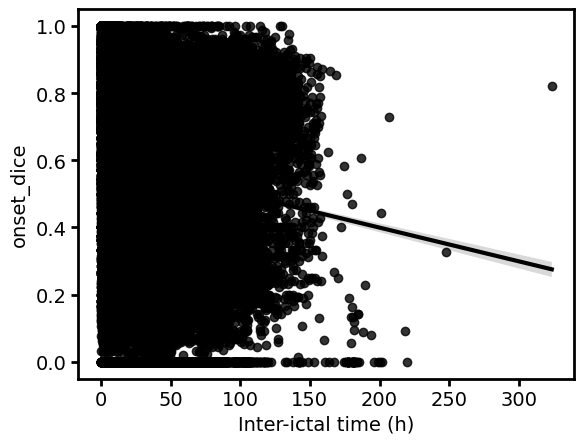

In [91]:
# sns.jointplot(pair_df_wmeta,x='temporal_distance',y='onset_dice',kind='hex')
sns.regplot(pair_df_wmeta,x='temporal_distance',y='onset_dice',color='black')
plt.xlabel('Inter-ictal time (h)')

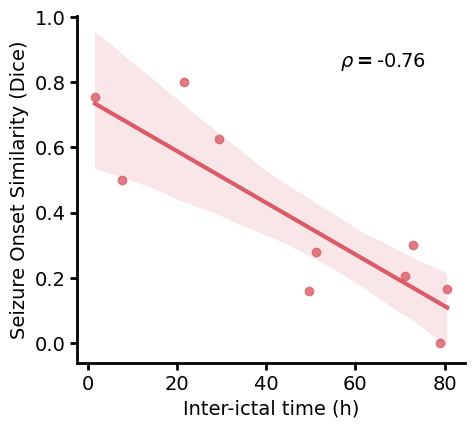

In [93]:
fig, ax = plt.subplots(figsize=(5,4.5))

# Select data for HUP172
data = pair_df_wmeta[pair_df_wmeta.patient=='HUP172']

# Plot the regression
sns.regplot(data, x='temporal_distance', y='onset_dice', color=sns.color_palette('plasma')[3], ax=ax)
sns.despine()

# Calculate Spearman correlation
from scipy.stats import spearmanr
r, p = spearmanr(data['temporal_distance'], data['onset_dice'])

# Add text annotation at top right with bold italic for Spearman R
ax.text(
    0.9, 0.9,
    r"$\bf{\it{\rho}} = $" + f"{r:.2f}",
    ha='right', va='top',
    transform=ax.transAxes,
    fontsize=14
)

plt.xlabel('Inter-ictal time (h)')
plt.ylabel('Seizure Onset Similarity (Dice)')
plt.savefig(ospj(figpath, 'temporal_distance_example.pdf'), bbox_inches='tight')

In [95]:
def plot_correlation_histogram(data, bins=np.linspace(-1, 1, 20), vbox_int=10,figsize=(4,4)):
    """
    Plots a histogram of correlation values in a single color (rocket_r[3]).

    Parameters:
    - data: array-like, the correlation values to plot.
    - bins: array-like, the bins for the histogram.
    - vbox_int: int, spacing for horizontal grid lines.
    """
    # Count data in each bin
    bin_width = bins[1] - bins[0]
    hist, _ = np.histogram(data, bins=bins)

    # Create the blocks
    fig, ax = plt.subplots(figsize=figsize)
    bar_color = sns.color_palette('rocket_r')[3]

    # Plot each block for all data
    for i, count in enumerate(hist):
        ax.bar(bins[i], count, width=bin_width, color=bar_color, edgecolor='none')
        
    for i in range(0, max(hist), vbox_int):
        plt.axhline(i, color='white')
    for i in bins:
        plt.axvline(i + bin_width / 2, color='white')
    
    return fig, ax

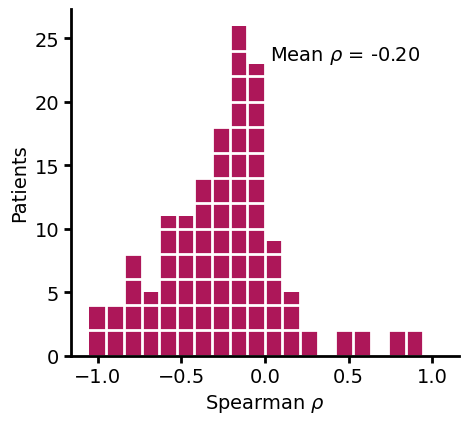

In [97]:
corrs_df = pair_df_wmeta.groupby('patient').apply(lambda x: spearmanr(x['temporal_distance'],x['onset_dice'])[0]).reset_index()
corrs_df.columns = ['patient','spearman_r']
plot_correlation_histogram(corrs_df['spearman_r'],vbox_int=2,figsize=(5,4.5))
# plt.axvline(corrs_df['spearman_r'].mean(),color='black',linestyle='--',linewidth=4)
mean_r = corrs_df['spearman_r'].mean()
plt.text(
    0.9, 0.9, 
    "Mean $\\rho$ = " + f"{mean_r:.2f}",
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=14
)

# sns.violinplot(corrs_df,x='spearman_r',split=True,width=0.5)
# sns.stripplot(corrs_df,x='spearman_r',color='black',alpha=0.1)
sns.despine()
plt.ylabel('Patients')
plt.xlabel('Spearman $\\rho$')
plt.savefig(ospj(figpath,'temporal_distance_spearman_histogram.pdf'),bbox_inches='tight')


## Spread patterns across the epileptiform spectrum

### Seizure severities

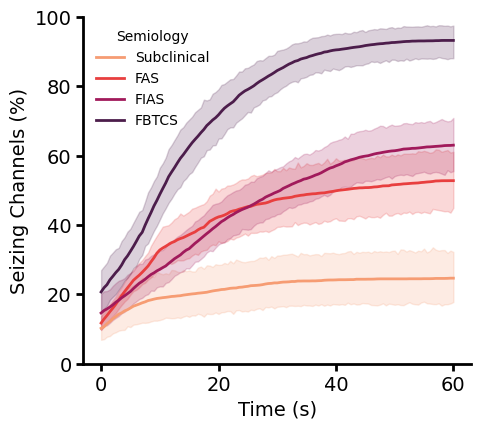

In [99]:
_,ax = plt.subplots(figsize=(5,4.5))
# ax.axvline(20,linewidth=2.5,linestyle='--',c='gray')
sz_types = ['Subclinical','FAS','FIAS','FBTCS']
sns.lineplot(
    data=long_df[long_df.Focality != 'diffuse'],
    x="time",
    y="percent_seizing",
    hue="Semiology",
    legend=True,
    palette = 'rocket_r',
    hue_order=['Subclinical','FAS','FIAS','FBTCS']
)
plt.ylabel('Seizing Channels (%)')
plt.xlabel('Time (s)')
plt.ylim([0,100])
# plt.title("Percent Seizing Over Time")
sns.despine()
plt.savefig(ospj(figpath,'seizure_severity.pdf'),bbox_inches='tight')
plt.show()

In [38]:
long_df_20 = long_df[long_df['time'] == 20]
wide_df = long_df_20.groupby('Semiology')['percent_seizing'].apply(list)
sc.stats.kruskal(*wide_df)

KruskalResult(statistic=np.float64(67.83552702421079), pvalue=np.float64(6.49753888864806e-14))

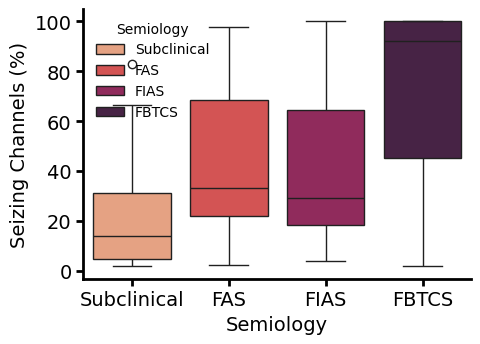

In [ ]:
plt.figure(figsize=(5,3.5))
sns.boxplot(long_df_20,x='Semiology',hue='Semiology',palette='rocket_r',y='percent_seizing',
            order=['Subclinical','FAS','FIAS','FBTCS'],
            hue_order = ['Subclinical','FAS','FIAS','FBTCS'])
plt.ylabel('Seizing Channels (%)')
plt.xlabel('Semiology')

sns.despine()
plt.savefig(ospj(figpath,'seizure_severity_discrete.pdf'),bbox_inches='tight')

In [43]:
all_ps = []
for i in range(len(sz_types)-1):
    x = long_df_20[long_df_20.Semiology == sz_types[i]].percent_seizing
    y  = long_df_20[long_df_20.Semiology == sz_types[i+1]].percent_seizing
    print(sz_types[i],': ',len(x),sz_types[i+1],': ',len(y))
    print(x.mean(),y.mean())
    u,p = sc.stats.mannwhitneyu(x,y)
    print(u,p)
    all_ps.append(p)
sc.stats.false_discovery_control(all_ps)

# Build list of comparisons and their results
comparison_rows = []
for i in range(len(sz_types)-1):
    comp = {
        'seizure_type_1': sz_types[i],
        'seizure_type_2': sz_types[i+1],
        'p_value': all_ps[i]
    }
    comparison_rows.append(comp)

# Add p-value rank and FDR-corrected p-value
comparison_df = pd.DataFrame(comparison_rows)
comparison_df['p_value_rank'] = comparison_df['p_value'].rank(method='min')
# For FDR, sc.stats.false_discovery_control returns an array of booleans, not p-values; instead, use the Benjamini/Hochberg FDR procedure below

rej, pvals_corr, _, _ = multipletests(comparison_df['p_value'], method='fdr_bh')
comparison_df['corrected_p_value'] = pvals_corr

comparison_df.to_csv(ospj(prodatapath,'seizure_type_pairwise_results.csv'), index=False)


Subclinical :  34 FAS :  51
21.22758545239903 42.34940547821521
451.0 0.00019351476671891684
FAS :  51 FIAS :  78
42.34940547821521 40.2807601780273
2110.5 0.5599729362601606
FIAS :  78 FBTCS :  74
40.2807601780273 71.80712145716235
1318.0 6.777044154048706e-09


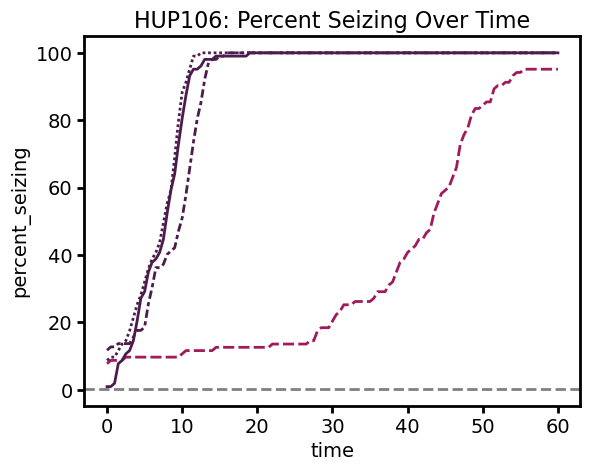

In [129]:
plt.axhline(.3,linestyle='--',color='gray')
sns.lineplot(
    data=long_df[long_df.patient == 'HUP106'],
    x="time",
    y="percent_seizing",
    hue="Semiology",
    palette = 'rocket_r',
    hue_order=['Subclinical','FAS','FIAS','FBTCS'],
    style='onset',
    legend=False
)
plt.title("HUP106: Percent Seizing Over Time")
plt.show()

In [130]:
sem_list = []
for pt, group in summary_df_wmeta.groupby('patient'):
    if (len(group.Semiology.unique()) > 1):# & (group['alt_focal'].iloc[0] != 'multifocal'):
        sem_list.append(group)
summary_df_wsem = pd.concat(sem_list).reset_index(drop=True)

In [131]:
seizure_rank = np.array(['Subclinical','FAS','FIAS','FBTCS'])
summary_df_wsem['Semiology'] = pd.Categorical(summary_df_wsem['Semiology'],categories=seizure_rank,ordered=True)
summary_df_wsem = summary_df_wsem.groupby('patient').apply(lambda x: x.sort_values('Semiology')).reset_index(drop=True)

### Spike loading

In [ ]:
# spike_df = pd.read_csv(ospj(datapath,'hup_thresholded.csv'))
# spike_df['recruitment_latency_thresh'] /= 500 # This is the sampling rate from the spike dataset

In [ ]:
# all_spike_fts = []
# for patient in tqdm(spike_df.pt_id.unique()):
#     group = spike_df[spike_df.pt_id == patient]
#     group.loc[:,'channel_label'] = clean_labels(group['channel_label'],patient)
#     group = group[group.channel_label.isin(remove_scalp_electrodes(group.channel_label.unique()))]
#     n_seqs = group.new_spike_seq.max()
#     probabilities = group.groupby(['new_spike_seq','channel_label'])['recruitment_latency_thresh'].mean().groupby('channel_label').count()/n_seqs
#     ch_mask = group.groupby('channel_label')['recruitment_latency_thresh'].count() > (n_seqs*0.05)
#     thresh_ch_list = ch_mask[ch_mask].index
#     group = group[group.channel_label.isin(thresh_ch_list)]
#     latencies = group.groupby(['new_spike_seq','channel_label'])['recruitment_latency_thresh'].mean().groupby('channel_label').median()
#     all_spike_fts.append({'patient': patient,
#                           'latency': latencies.to_dict(),
#                           'probability': probabilities.to_dict()})
# all_spike_fts_df = pd.DataFrame(all_spike_fts)
# all_spike_fts_df.to_pickle(ospj(prodatapath,'all_spike_fts.pkl'))

In [ ]:
all_spike_fts_df = pd.read_pickle(ospj(prodatapath,'all_spike_fts.pkl'))

In [ ]:
summary_df_wspikes = summary_df_wmeta.merge(all_spike_fts_df,on='patient',how='inner')

In [ ]:
summary_df_wspikes.loc[0,'onset_ndd_ind'][0]

LA01-LA02    1.596092
LA02-LA03    2.205025
LA03-LA04    1.514484
LA04-LA05    0.775895
LA05-LA06    0.951427
               ...   
RD03-RD04    0.928609
RD04-RD05    0.930479
RD05-RD06    0.797719
RD06-RD07    0.864366
RD07-RD08    1.002658
Length: 104, dtype: float32

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_55489/2060322493.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(labels=ax2.get_yticklabels(),color='orange')
/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_55489/2060322493.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels=ax2.get_xticklabels(),rotation=90)


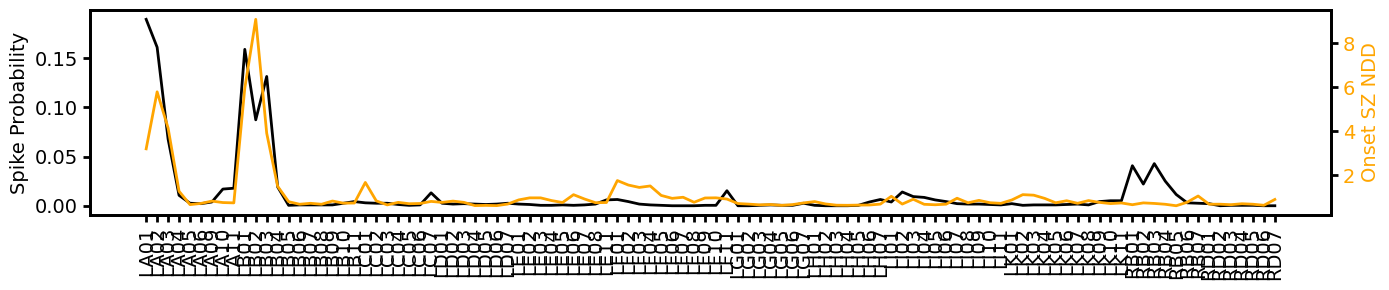

In [ ]:
row = summary_df_wspikes.loc[0,:]
onset = row.SOZ_region
patient = row.patient
outcome = row.outcome
ndd_onset_mono = row.onset_ndd_ind[3].copy()
# ndd_onset_mono = row.onset_ndd_cum[time_idx].copy()
ndd_onset_mono.index = [x.split('-')[0] for x in ndd_onset_mono.index]
all_ndd_spikes = {key: 0 for key in ndd_onset_mono.index}
for key in row.probability.keys():
    all_ndd_spikes[key] = row.probability[key]
all_ndd_spikes_df = pd.Series(all_ndd_spikes).reindex(ndd_onset_mono.index)
fig, ax1 = plt.subplots(figsize=(14,3),)
ax1.plot(all_ndd_spikes_df,color='black')
ax1.set_ylabel('Spike Probability',color='black')
ax2=ax1.twinx()
ax2.plot(ndd_onset_mono,color='orange')
ax2.set_yticklabels(labels=ax2.get_yticklabels(),color='orange')
ax2.set_ylabel('Onset SZ NDD',color='orange')
ax1.set_xticklabels(labels=ax2.get_xticklabels(),rotation=90)
plt.tight_layout()
# sns.despine()

Ok so i need to get for each spike train the average latency. I also need to get the spike probability. Maybe have an absolute threshold of number of spikes required to get included in the latency calculation. Right now the pipeline is go through each spike train and append the latency.


### Spike and seizure onset

In [ ]:
def spike_onset_func(row,time_idx = 3):
    onset = row.SOZ_region
    patient = row.patient
    outcome = row.outcome
    ndd_onset_mono = row.onset_ndd_ind[time_idx].copy()
    # ndd_onset_mono = row.onset_ndd_cum[time_idx].copy()
    ndd_onset_mono.index = [x.split('-')[0] for x in ndd_onset_mono.index]
    all_ndd_spikes = {key: 0 for key in ndd_onset_mono.index}
    for key in row.probability.keys():
        all_ndd_spikes[key] = row.probability[key]
    all_ndd_spikes_df = pd.Series(all_ndd_spikes).reindex(ndd_onset_mono.index)
    if any(ndd_onset_mono.isna()) | (len(ndd_onset_mono) < 2):
        return pd.Series([np.nan,np.nan],index=['onset_r','onset_p'])
    else:
        r,p = pearsonr(all_ndd_spikes_df,ndd_onset_mono,alternative='greater')
        return pd.Series([r,p,onset,patient,outcome],index=['onset_r','onset_p','onset','patient','outcome'])

In [ ]:
summary_df_wspikes.columns

NameError: name 'summary_df_wspikes' is not defined

In [ ]:
summary_df_wspikes.head()

In [ ]:
time_idxs = [1,3,5,10,15,20,25,30,40]
all_spike_onsets = []
all_time_idxs = []
all_onsets = []
all_pts = []
all_outcomes = []
for i in range(len(time_idxs)):
    all_onset_spike_ps = summary_df_wspikes[(summary_df_wspikes.all_focal == 'focal')& (summary_df_wspikes.SOZ_region.isin(['mesial temporal','temporal neocortical']))].apply(spike_onset_func,time_idx = i,axis=1)
    # & (summary_df_wspikes.SOZ_region != 'other cortex')
    # all_onset_spike_ps = summary_df_wspikes.apply(spike_onset_func,time_idx = i,axis=1)

    all_spike_onsets.extend(all_onset_spike_ps.onset_r.to_list())
    all_time_idxs.extend([time_idxs[i]]*len(all_onset_spike_ps))
    all_onsets.extend(all_onset_spike_ps.onset.to_list())
    all_pts.extend(all_onset_spike_ps.patient.to_list())
    all_outcomes.extend(all_onset_spike_ps.outcome.to_list())

Traceback (most recent call last):
  File "_pydevd_bundle\\pydevd_cython.pyx", line 1609, in _pydevd_bundle.pydevd_cython.handle_exception
  File "/Users/wojemann/Documents/CNT/DSOSD/DSOSD_env/lib/python3.9/site-packages/debugpy/_vendored/pydevd/pydevd.py", line 2185, in do_wait_suspend
    keep_suspended = self._do_wait_suspend(thread, frame, event, arg, trace_suspend_type, from_this_thread, frames_tracker)
  File "/Users/wojemann/Documents/CNT/DSOSD/DSOSD_env/lib/python3.9/site-packages/debugpy/_vendored/pydevd/pydevd.py", line 2254, in _do_wait_suspend
    notify_event.wait(wait_timeout)
  File "/Users/wojemann/opt/anaconda3/lib/python3.9/threading.py", line 574, in wait
    signaled = self._cond.wait(timeout)
  File "/Users/wojemann/opt/anaconda3/lib/python3.9/threading.py", line 316, in wait
    gotit = waiter.acquire(True, timeout)
KeyboardInterrupt


: 

: 

In [ ]:
spike_onset_agreement_df = pd.DataFrame(np.concatenate((np.array(all_time_idxs).reshape(-1,1),np.array(all_spike_onsets).reshape(-1,1),np.array(all_onsets).reshape(-1,1),np.array(all_pts).reshape(-1,1),np.array(all_outcomes).reshape(-1,1)),axis=1),columns=['time','spike-onset-r','onset','patient','outcome'],).dropna(axis=0)

In [ ]:
spike_onset_agreement_df['spike-onset-r'] = spike_onset_agreement_df['spike-onset-r'].astype(float)
spike_onset_agreement_df = spike_onset_agreement_df.dropna(subset=['spike-onset-r'])
spike_onset_agreement_df['time'] = spike_onset_agreement_df['time'].astype(float)

In [ ]:
onsets = ['mesial temporal','temporal neocortical']
sub_spike_df = spike_onset_agreement_df[spike_onset_agreement_df.onset.isin(onsets)]
sub_spike_df_pt = sub_spike_df.groupby(['patient','time']).agg({
                                                             'onset': 'max', 
                                                             'spike-onset-r': 'median',
                                                             'outcome':'max'
                                                            }).reset_index()
sub_spike_df_pt = sub_spike_df_pt.replace({'1.0': 'good','0.0': 'poor'})

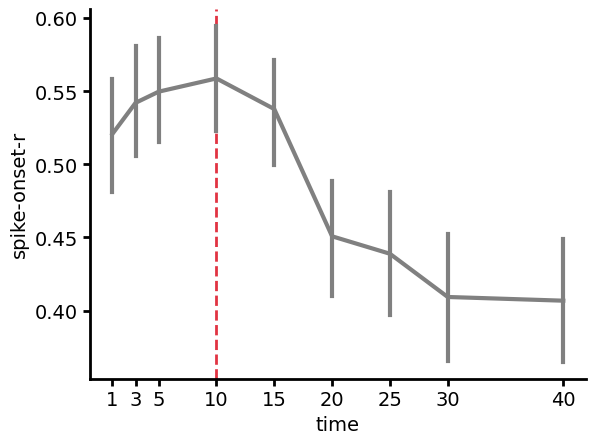

In [ ]:
plt.axvline(10,color=sns.color_palette('rocket_r')[2],linestyle='--',linewidth=2)
sns.lineplot(spike_onset_agreement_df,x='time',y='spike-onset-r',err_style='bars',color='gray',linewidth=3,err_kws={'linewidth':3})
plt.xticks(time_idxs)
sns.despine()

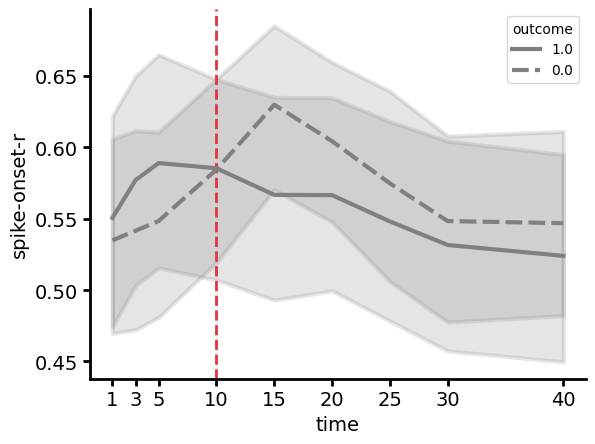

In [ ]:
plt.axvline(10,color=sns.color_palette('rocket_r')[2],linestyle='--',linewidth=2)
sns.lineplot(spike_onset_agreement_df,style='outcome',style_order=['1.0','0.0'],x='time',y='spike-onset-r',err_style='band',color='gray',linewidth=3,err_kws={'linewidth':3})
plt.xticks(time_idxs)
sns.despine()

In [ ]:
print(sc.stats.mannwhitneyu(spike_onset_agreement_df[spike_onset_agreement_df.time == 10]['spike-onset-r'],
         spike_onset_agreement_df[spike_onset_agreement_df.time == 1]['spike-onset-r']))
print(cohens_d(spike_onset_agreement_df[spike_onset_agreement_df.time == 10]['spike-onset-r'],
         spike_onset_agreement_df[spike_onset_agreement_df.time == 1]['spike-onset-r']))

MannwhitneyuResult(statistic=47436.0, pvalue=0.25131957019385764)
0.11662845333958248


In [ ]:
plot_onset_spike_ps = summary_df_wspikes[(summary_df_wspikes.all_focal == 'focal')& (summary_df_wspikes.SOZ_region.isin(['mesial temporal','temporal neocortical']))].apply(spike_onset_func,time_idx = 3,axis=1)

Text(0.5, 1.0, '')

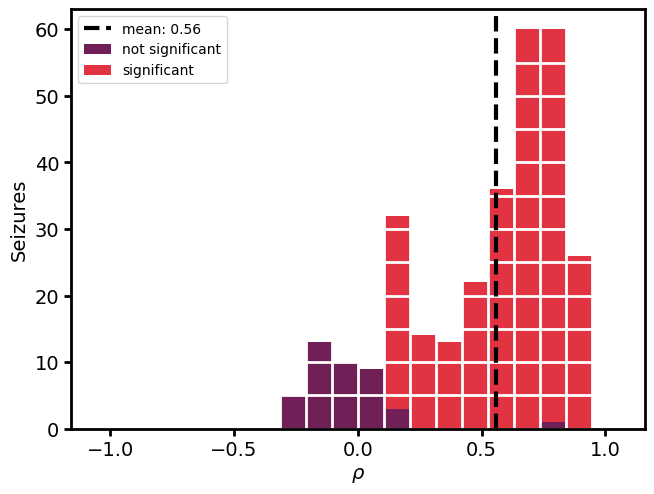

In [ ]:
_,ax=plot_sig_nsig(plot_onset_spike_ps.onset_r[plot_onset_spike_ps.onset_p < 0.05],plot_onset_spike_ps.onset_r[plot_onset_spike_ps.onset_p >= 0.05],vbox_int=5)
ax.axvline(plot_onset_spike_ps.onset_r.mean(),linestyle='--',color='black',linewidth=3,label=f'mean: {plot_onset_spike_ps.onset_r.mean():.2f}')
plt.legend()
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('Seizures')
plt.title('')

In [ ]:
# onsets = ['mesial temporal','temporal neocortical','other cortex']


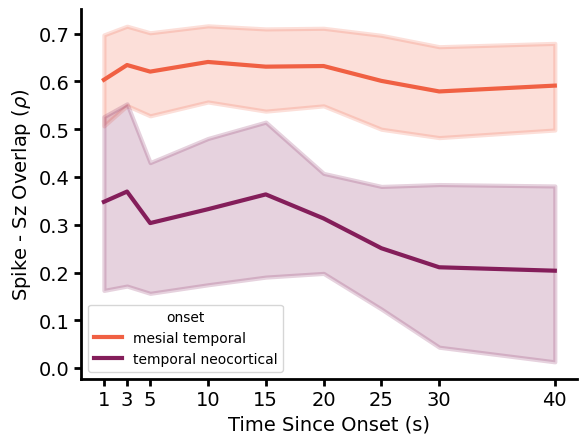

In [ ]:
sns.lineplot(sub_spike_df_pt,x='time',y='spike-onset-r',err_style='band',hue='onset',hue_order=onsets,palette='rocket_r',linewidth=3,err_kws={'linewidth':3},estimator='mean')
plt.xticks(time_idxs)
plt.xlabel('Time Since Onset (s)')
plt.ylabel(r'Spike - Sz Overlap ($\rho$)')
sns.despine()

MannwhitneyuResult(statistic=153.0, pvalue=0.040001275672727536)


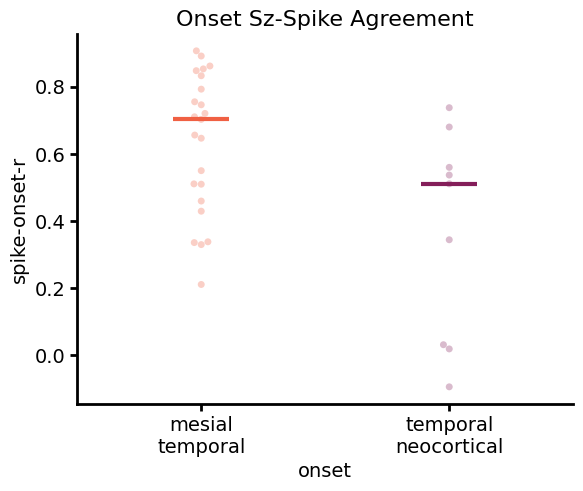

In [ ]:
# sns.boxplot(sub_spike_df[sub_spike_df.time==10],hue='onset',order=['mesial temporal','temporal neocortical','other cortex'],hue_order=['mesial temporal','temporal neocortical','other cortex'],x='onset',y='spike-onset-r',palette='rocket_r',whis=100)
sub_spike_10 = sub_spike_df_pt[sub_spike_df_pt.time==3]

ax = sns.swarmplot(sub_spike_10,hue='onset',order=onsets,
              hue_order=onsets,
              x='onset',y='spike-onset-r',
              palette='rocket_r',
              alpha=0.3)

sns.pointplot(sub_spike_10,
              hue='onset',
              palette='rocket_r',
              linestyle="none", errorbar=None,
              marker="_", markersize=40, markeredgewidth=3,
              order=onsets,
              hue_order=onsets,
              x='onset',y='spike-onset-r',
              ax = ax,
              estimator='median')
plt.title('Onset Sz-Spike Agreement')
# plt.xticks(ticks=[0,1,2],labels=['mesial\ntemporal','temporal\nneocortical','other cortex'])
plt.xticks(ticks=[0,1],labels=['mesial\ntemporal','temporal\nneocortical'])
sns.despine()
for i in range(len(onsets)):
    for j in range(i+1,len(onsets)):
        print(sc.stats.mannwhitneyu(sub_spike_10[sub_spike_10.onset == onsets[i]]['spike-onset-r'],
                        sub_spike_10[sub_spike_10.onset == onsets[j]]['spike-onset-r']))

### Outcome and Spike-Sz concordance

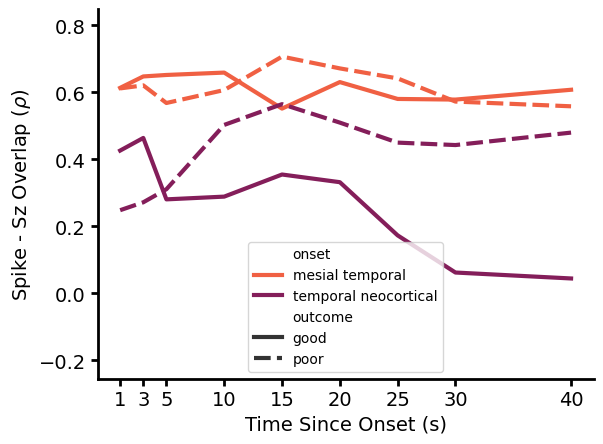

In [ ]:
sns.lineplot(sub_spike_df_pt,x='time',y='spike-onset-r',err_style='band',hue='onset',hue_order=onsets,palette='rocket_r',linewidth=3,err_kws={'linewidth':0,'alpha':0},estimator='mean',style='outcome',style_order=['good','poor'])
plt.xticks(time_idxs)
plt.xlabel('Time Since Onset (s)')
plt.ylabel(r'Spike - Sz Overlap ($\rho$)')
sns.despine()

MannwhitneyuResult(statistic=108.0, pvalue=0.03571172886492605)
-0.9631829349074675
0.72


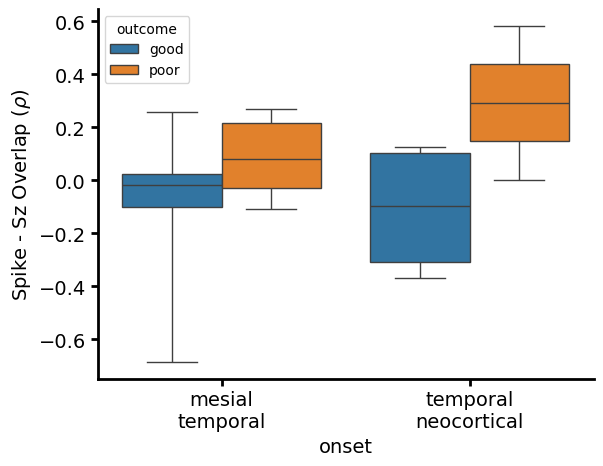

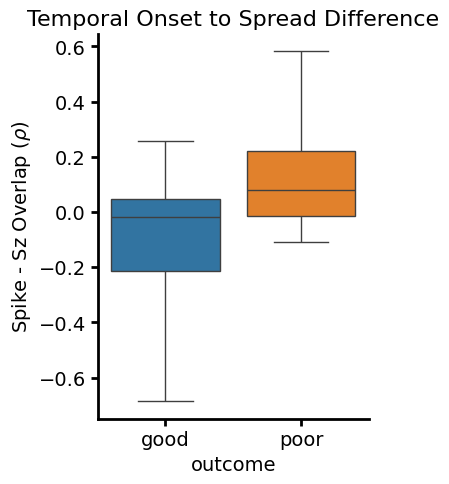

In [ ]:
sub_spike_10.loc[:,'spike-onset-r'] = sub_spike_df_pt[sub_spike_df_pt.time==15]['spike-onset-r'].to_numpy() - sub_spike_df_pt[sub_spike_df_pt.time == 3]['spike-onset-r'].to_numpy()
# sub_spike_10.loc[:,'spike-onset-r'] = sub_spike_df_pt[sub_spike_df_pt.time==15]['spike-onset-r'].to_numpy()
# sub_spike_10.loc[:,'spike-onset-r'] = sub_spike_df_pt[sub_spike_df_pt.time == 3]['spike-onset-r'].to_numpy()

ax = sns.boxplot(sub_spike_10,hue='outcome',order=onsets,hue_order=['good','poor'],
              x='onset',y='spike-onset-r',whis=100)
plt.ylabel(r'Spike - Sz Overlap ($\rho$)')
plt.xticks(ticks=[0,1],labels=['mesial\ntemporal','temporal\nneocortical'])#,'other cortex'])
sns.despine()
sub_spike_temporal = sub_spike_10[sub_spike_10.onset != 'other cortex']
plt.figure(figsize=(3.5,5))
sns.boxplot(sub_spike_temporal,hue='outcome',order=['good','poor'],hue_order=['good','poor'],
              x='outcome',y='spike-onset-r',whis=100,)
plt.ylabel(r'Spike - Sz Overlap ($\rho$)')
plt.title('Temporal Onset to Spread Difference')
sns.despine()
print(sc.stats.mannwhitneyu(sub_spike_temporal[sub_spike_temporal.outcome == 'poor']['spike-onset-r'],
                      sub_spike_temporal[sub_spike_temporal.outcome == 'good']['spike-onset-r'],alternative='greater'))
print(cohens_d(sub_spike_temporal[sub_spike_temporal.outcome == 'good']['spike-onset-r'],
                      sub_spike_temporal[sub_spike_temporal.outcome == 'poor']['spike-onset-r']))
print(108/(len(sub_spike_temporal[sub_spike_temporal.outcome == 'good']['spike-onset-r'])*len(sub_spike_temporal[sub_spike_temporal.outcome == 'poor']['spike-onset-r'])))


## Seizure Spread Clinical Models

In [255]:
resection_masks = pd.read_pickle(ospj(metapath,'resection_masks.pkl'))
resection_masks['resected'] = resection_masks['resected'] == 1
# implanted_rois = resection_masks.groupby(['rid'])[['roiNum']].nunique().reset_index()
# implanted_rois['rid'] = implanted_rois['rid'].astype(int)
# implanted_rois['n_rois'] = implanted_rois.pop('roiNum')
# resection_masks = resection_masks.merge(implanted_rois,on='rid',how='inner')

rid_hup = pd.read_csv(ospj(prodatapath,'electrode_localizations','summary.csv'))
rid_hup = rid_hup.dropna(subset=['hupid'])
rid_hup['patient'] = rid_hup['hupid'].apply(lambda x: 'HUP'+str(int(x)).zfill(3))
resection_masks = resection_masks.merge(rid_hup[['patient','rid']],on='rid',how='left')

all_outcome_df = pd.read_csv(ospj(prodatapath,f'seizure_spread_outcome_mdl-{mdl_str}_thresh-{thresh_str}.csv'))
all_outcome_df['label'] = all_outcome_df.pop('labels')
all_outcome_df = all_outcome_df.merge(resection_masks[['patient','label','resected']],on=['patient','label'],how='left')

# implanted_rois = all_outcome_df.groupby(['patient'])[['roiNum']].nunique().reset_index()
# implanted_rois['n_rois'] = implanted_rois.pop('roiNum')
# all_outcome_df = all_outcome_df.merge(implanted_rois,on='patient',how='left')

In [133]:
all_outcome_df.to_csv(ospj(prodatapath,f'katie.csv'),index=False) 

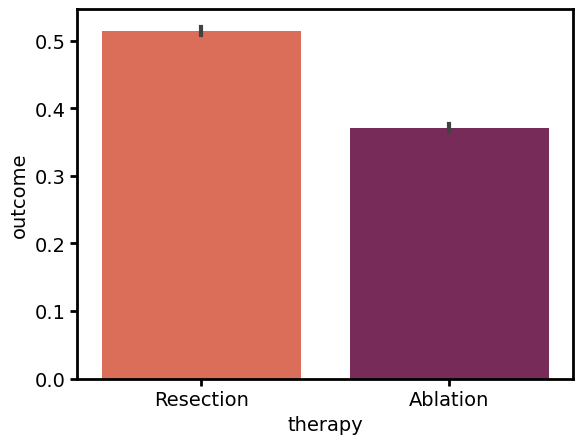

In [134]:
# all_outcome_df = all_outcome_df[all_outcome_df.target == 'MTL']
sns.barplot(all_outcome_df,x='therapy',y='outcome',palette='rocket_r')
all_outcome_df['time_inv'] = all_outcome_df['time'].copy()
# all_outcome_df.time_inv += 1e-10
# all_outcome_df.time_inv = 1/all_outcome_df.time_inv

### ATL Study

In [135]:
atl_outcome_df = all_outcome_df[all_outcome_df.atl].reset_index()
print(atl_outcome_df.patient.nunique())
temporal_set = ['temporal','Hippocampus','parahippocampal','Amygdala','entorhinal']
mtl_set = ['Hippocampus','Amygdala']
atl_outcome_df['lh'] = atl_outcome_df.laterality.copy() + 'H'
atl_outcome_df['time'] += 1
# Take the minimum seizing time per channel per region per patient per seizure to aggergate channesl within regions
atl_outcome_df = atl_outcome_df.groupby(['patient','onset','outcome','lh','roi'],as_index=False)['time'].mean()
atl_outcome_df['time'] = atl_outcome_df['time'].fillna(np.inf)
atl_outcome_df.time = 1/atl_outcome_df.time
print(atl_outcome_df.time.isna().sum())
# Replace 'Left-Hippocampus' with 'lh-Hippocampus', 'Right-Hippocampus' with 'rh-Hippocampus'
# Replace 'Left-Amygdala' with 'lh-Amygdala', 'Right-Amygdala' with 'rh-Amygdala'
atl_outcome_df['roi'] = atl_outcome_df['roi'].replace({
    'Left-Hippocampus': 'lh-Hippocampus',
    'Right-Hippocampus': 'rh-Hippocampus',
    'Left-Amygdala': 'lh-Amygdala',
    'Right-Amygdala': 'rh-Amygdala'
})

# Assign channels to mesial, temporal, or other regions
atl_outcome_df['temporal'] = 'other'

atl_outcome_df.loc[atl_outcome_df.apply(lambda x: any([r in x.roi for r in temporal_set]) and (any([r not in x.roi.upper() for r in mtl_set])) and (x.lh in x.roi.upper()),axis=1),'temporal'] = 'mesial'
atl_outcome_df.loc[atl_outcome_df.apply(lambda x: any([r.lower() in x.roi.lower() for r in mtl_set]) and (x.lh in x.roi.upper()),axis=1),'temporal'] = 'mesial'

atl_timing_df = atl_outcome_df.groupby(['patient','outcome','onset','temporal'],as_index=False)['time'].mean()

22
0


#### mesial to lateral spread

In [136]:
# Aggregate by patient, outcome, onset, temporal, and compute mean 'time'
# Will keep patient, outcome, onset columns, and calculate mesial, neocortical times and their difference
# First, merge onset and outcome info from the grouped dataframe
keep_cols = ['patient', 'outcome', 'onset', 'temporal', 'time']

# Pivot so each patient has columns for mesial and neocortical times, keeping outcome and onset as columns
patient_temporal_time = atl_timing_df.pivot(index=['patient', 'outcome', 'onset'], columns='temporal', values='time').reset_index()

# Only keep patients with both mesial and neocortical times
diff_df = patient_temporal_time.dropna(subset=['mesial', 'other']).copy()
diff_df['diff_time'] = diff_df['other'] - diff_df['mesial']
diff_df = diff_df.groupby(['patient','outcome'],as_index=False)['diff_time'].mean()

# This final DataFrame has: patient, outcome, onset, mesial, neocortical, diff_time
diff_time_df = diff_df[['patient', 'outcome', 'diff_time']]

In [137]:
diff_time_df

,patient,outcome,diff_time
0,HUP074,1.0,-0.163686
1,HUP075,0.0,-0.158498
2,HUP078,0.0,-0.139999
3,HUP080,1.0,0.219584
4,HUP086,1.0,-0.635780
5,HUP094,1.0,-0.624192
6,HUP105,1.0,-0.269018
7,HUP106,1.0,-0.067277
8,HUP107,1.0,-0.061188
9,HUP110,0.0,0.042122


<Axes: ylabel='diff_time'>

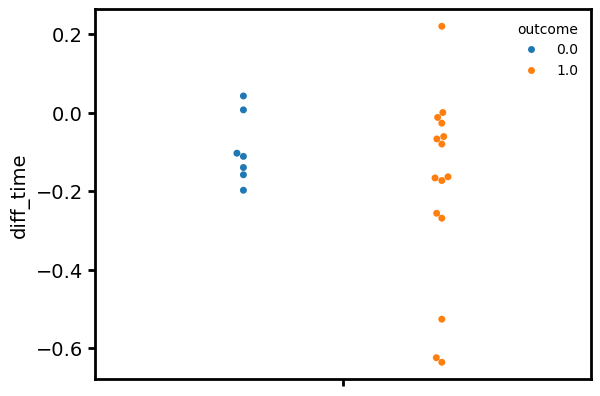

In [138]:
sns.swarmplot(data=diff_time_df,y='diff_time',hue='outcome',dodge=True)

### Other studies

<Axes: xlabel='outcome', ylabel='time'>

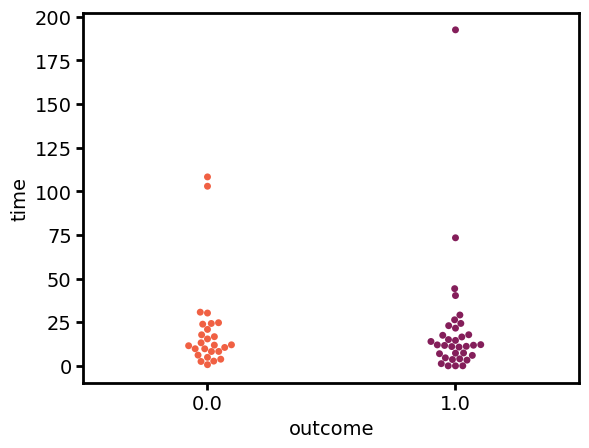

In [139]:
wm_mask_spread = all_outcome_df[all_outcome_df['roi'].apply(lambda x: 'white'  in x)].groupby(['patient','onset','outcome'],as_index=False)['time'].apply(lambda x: np.mean(x))
wm_mask_spread = wm_mask_spread.groupby(['patient','outcome'],as_index=False)['time'].apply(lambda x: np.mean(x))
sns.swarmplot(wm_mask_spread,x='outcome',y='time',palette='rocket_r')

Best threshold: nan
Best accuracy: 0.5645161290322581


<Axes: xlabel='threshold', ylabel='sensitivity'>

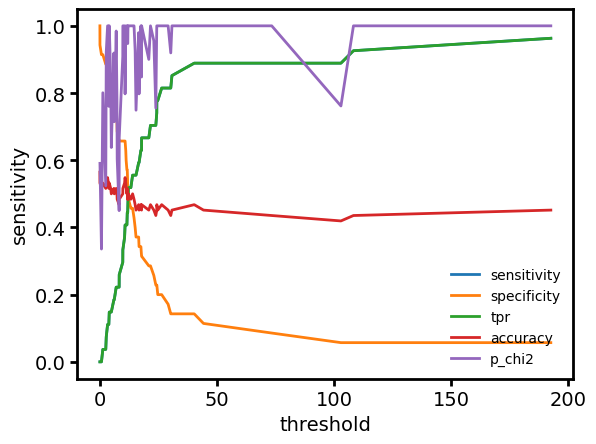

In [140]:
# Iterate through possible time thresholds (from min to max in temporal_diff_df['time'])
# For each threshold, classify outcome as 1 if time > threshold else 0, and compute accuracy, sensitivity, specificity, and tpr
best_threshold = None
best_acc = 0
results = []

y_true = wm_mask_spread['outcome'].astype(int).values == 0
for thresh in wm_mask_spread['time'].unique():
    y_pred = (wm_mask_spread['time'] < thresh).astype(int).values

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # True positive rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan  # True negative rate
    tpr = sensitivity  # synonym for clarity
    # Calculate chi-squared p-value for each threshold and append it as a performance metric
    contingency = np.array([
        [(y_pred == 1).sum(), (y_pred == 0).sum()],
        [(y_true == 1).sum(), (y_true == 0).sum()]
    ])
    cm = confusion_matrix(y_true, y_pred)
    if thresh in [1,3,5,10,15,20,30]:
        print(cm)
    # This table should be for observed (pred, actual)
    # To get a proper 2x2 table, use:
    chi2_table = np.zeros((2,2), dtype=int)
    chi2_table[0,0] = tp   # predicted 1, true 1
    chi2_table[0,1] = fp   # predicted 1, true 0
    chi2_table[1,0] = fn   # predicted 0, true 1
    chi2_table[1,1] = tn   # predicted 0, true 0
    try:
        from scipy.stats import chi2_contingency
        chi2, p_chi2, _, _ = chi2_contingency(chi2_table)
    except Exception:
        p_chi2 = np.nan
    
    results.append({
        'threshold': thresh,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tpr': tpr,
        'p_chi2': p_chi2
    })

    if accuracy > best_acc:
        best_acc = accuracy
        best_threshold = thresh

print("Best threshold:", best_threshold)
print("Best accuracy:", best_acc)
results_df = pd.DataFrame(results)

sns.lineplot(results_df,x='threshold',y='sensitivity',label='sensitivity')
sns.lineplot(results_df,x='threshold',y='specificity',label='specificity')
sns.lineplot(results_df,x='threshold',y='tpr',label='tpr')
sns.lineplot(results_df,x='threshold',y='accuracy',label='accuracy')
sns.lineplot(results_df,x='threshold',y='p_chi2',label='p_chi2')

<Axes: xlabel='outcome', ylabel='diff_time'>

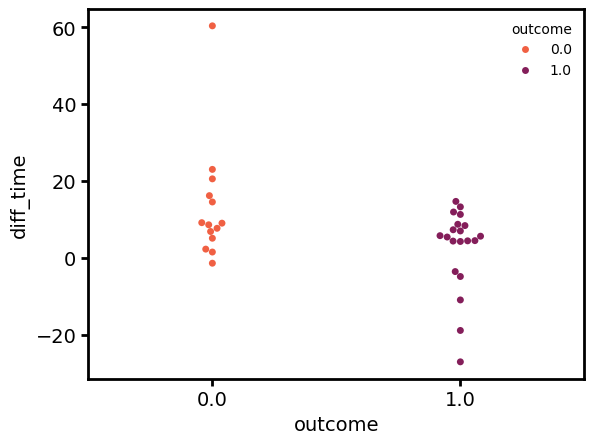

In [141]:
# Group to get mean time per patient, outcome, and resected status (True/False)
recruited_means = (
    all_outcome_df
    [all_outcome_df['roi'].apply(lambda x: 'white' not in x)]
    .dropna(subset=['resected'])
    .groupby(['patient','onset','outcome', 'resected'], as_index=False)['time']
    .mean()
)
recruited_means = recruited_means.groupby(['patient','outcome','resected'],as_index=False)['time'].apply(lambda x: np.mean(x))

# Pivot so columns are resected (True, False), indexed by patient and outcome
recruited_pivot = recruited_means.pivot_table(index=['patient', 'outcome'], columns='resected', values='time')

# Drop patients who don't have both True and False for resected
recruited_pivot = recruited_pivot.dropna(subset=[True, False])

# Compute absolute difference between resected True and False mean times
resected_diff_df = recruited_pivot.apply(lambda x: x[False] - x[True], axis=1).reset_index()
resected_diff_df.columns = ['patient', 'outcome', 'diff_time']

sns.swarmplot(resected_diff_df, x='outcome', y='diff_time', hue='outcome',palette='rocket_r')

Best threshold: -27.092373737373737
Best accuracy: 0.5882352941176471


<Axes: xlabel='threshold', ylabel='sensitivity'>

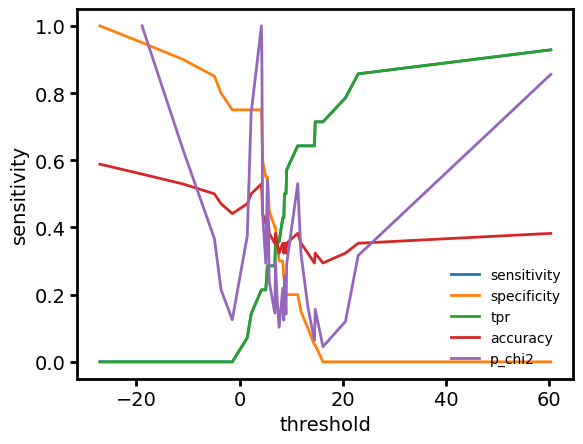

In [142]:
best_threshold = None
best_acc = 0
results = []

y_true = resected_diff_df['outcome'].astype(int).values == 0
for thresh in np.unique(resected_diff_df['diff_time']):
    y_pred = (resected_diff_df['diff_time'] < thresh).astype(int).values

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # True positive rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan  # True negative rate
    tpr = sensitivity  # synonym for clarity
    # Calculate chi-squared p-value for each threshold and append it as a performance metric
    contingency = np.array([
        [(y_pred == 1).sum(), (y_pred == 0).sum()],
        [(y_true == 1).sum(), (y_true == 0).sum()]
    ])
    cm = confusion_matrix(y_true, y_pred)
    
    # This table should be for observed (pred, actual)
    # To get a proper 2x2 table, use:
    chi2_table = np.zeros((2,2), dtype=int)
    chi2_table[0,0] = tp   # predicted 1, true 1
    chi2_table[0,1] = fp   # predicted 1, true 0
    chi2_table[1,0] = fn   # predicted 0, true 1
    chi2_table[1,1] = tn   # predicted 0, true 0
    if thresh in np.array([1,3,5,10,15,20,30]):
        print(chi2_table)
    try:
        from scipy.stats import chi2_contingency
        chi2, p_chi2, _, _ = chi2_contingency(chi2_table)
    except Exception:
        p_chi2 = np.nan
    
    results.append({
        'threshold': thresh,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tpr': tpr,
        'p_chi2': p_chi2
    })

    if accuracy > best_acc:
        best_acc = accuracy
        best_threshold = thresh

print("Best threshold:", best_threshold)
print("Best accuracy:", best_acc)
results_df = pd.DataFrame(results)

sns.lineplot(results_df,x='threshold',y='sensitivity',label='sensitivity')
sns.lineplot(results_df,x='threshold',y='specificity',label='specificity')
sns.lineplot(results_df,x='threshold',y='tpr',label='tpr')
sns.lineplot(results_df,x='threshold',y='accuracy',label='accuracy')
sns.lineplot(results_df,x='threshold',y='p_chi2',label='p_chi2')

<Axes: xlabel='outcome', ylabel='time'>

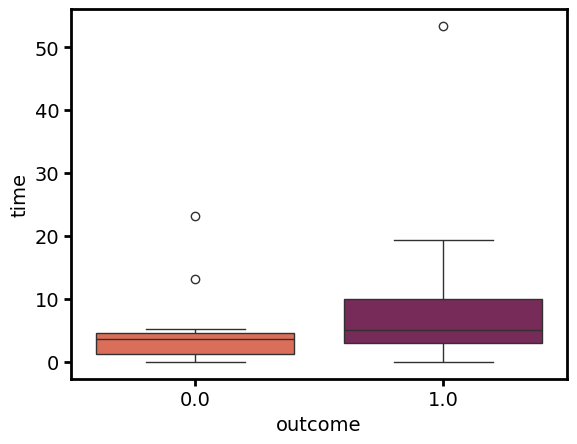

In [143]:
temporal_outcome_df = all_outcome_df[all_outcome_df.roi.apply(lambda x: 'white' not in x)]

temporal_set = ['temporal','Hippocampus','parahippocampal','Amygdala','temporalpole','entorhinal']
# temporal_set = ['Hippocampus','Amygdala']

def lr_temporal_assign(roi):
    if any([x in roi.lower() for x in ['lh','left']]):
        side_key = 'L'
    elif any([x in roi.lower() for x in ['rh','right']]):
        side_key = 'R'

    if any(x in roi for x in temporal_set):
        return side_key + 'TL'
    else:
        return side_key + 'OC'

temporal_outcome_df['lr_temporal'] = temporal_outcome_df.roi.apply(lr_temporal_assign)

# Drop patients from temporal_outcome_df who do not have both LTL and RTL
patients_with_LTL_RTL = (
    temporal_outcome_df.groupby('patient')['lr_temporal']
    .apply(lambda x: {'LTL', 'RTL'}.issubset(set(x)))
)
patients_to_keep = patients_with_LTL_RTL[patients_with_LTL_RTL].index
temporal_outcome_df = temporal_outcome_df[temporal_outcome_df['patient'].isin(patients_to_keep)].copy()

temporal_spread_df = temporal_outcome_df.groupby(['patient','outcome','lr_temporal'], as_index=False)['time'].mean()
temporal_diff_df = temporal_spread_df.groupby(['patient','outcome'])[['lr_temporal','time']].apply(lambda x: abs(x[x.lr_temporal == 'LTL'].time.values[0] - x[x.lr_temporal == 'RTL'].time.values[0])).reset_index()
temporal_diff_df.columns = ['patient','outcome','time']
    # lambda x: np.abs(x[x.lr_temporal == 'LTL'] - x[x.lr_temporal == 'RTL']))
# sns.barplot(temporal_spread_df,x='outcome',y='time',hue='lr_temporal',palette='rocket_r')
# plt.figure()
sns.boxplot(temporal_diff_df,x='outcome',y='time',palette='rocket_r')

[[ 3  2]
 [ 9 16]]
[[ 5  5]
 [ 7 13]]
[[9 9]
 [3 9]]
[[10 13]
 [ 2  5]]
[[11 16]
 [ 1  2]]
[[11 17]
 [ 1  1]]
[[12 17]
 [ 0  1]]
Best threshold: 1.5
Best accuracy: 0.6666666666666666


<Axes: xlabel='threshold', ylabel='sensitivity'>

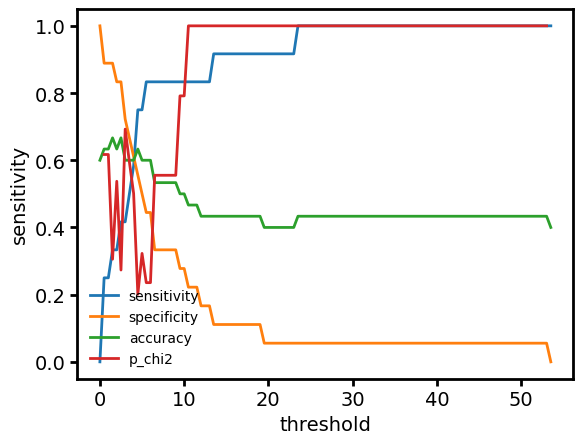

In [144]:
# Iterate through possible time thresholds (from min to max in temporal_diff_df['time'])
# For each threshold, classify outcome as 1 if time > threshold else 0, and compute accuracy, sensitivity, specificity, and tpr
best_threshold = None
best_acc = 0
results = []

y_true = temporal_diff_df['outcome'].astype(int).values == 0
for thresh in np.arange(0, temporal_diff_df['time'].max() + 0.5, 0.5):
    y_pred = (temporal_diff_df['time'] < thresh).astype(int).values

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # True positive rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan  # True negative rate
    tpr = sensitivity  # synonym for clarity
    # Calculate chi-squared p-value for each threshold and append it as a performance metric
    contingency = np.array([
        [(y_pred == 1).sum(), (y_pred == 0).sum()],
        [(y_true == 1).sum(), (y_true == 0).sum()]
    ])
    cm = confusion_matrix(y_true, y_pred)
    
    # This table should be for observed (pred, actual)
    # To get a proper 2x2 table, use:
    chi2_table = np.zeros((2,2), dtype=int)
    chi2_table[0,0] = tp   # predicted 1, true 1
    chi2_table[0,1] = fp   # predicted 1, true 0
    chi2_table[1,0] = fn   # predicted 0, true 1
    chi2_table[1,1] = tn   # predicted 0, true 0
    if thresh in [1,3,5,10,15,20,30]:
        print(chi2_table)
    try:
        from scipy.stats import chi2_contingency
        chi2, p_chi2, _, _ = chi2_contingency(chi2_table)
    except Exception:
        p_chi2 = np.nan
    
    results.append({
        'threshold': thresh,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tpr': tpr,
        'p_chi2': p_chi2
    })

    if accuracy > best_acc:
        best_acc = accuracy
        best_threshold = thresh

print("Best threshold:", best_threshold)
print("Best accuracy:", best_acc)
results_df = pd.DataFrame(results)

sns.lineplot(results_df,x='threshold',y='sensitivity',label='sensitivity')
sns.lineplot(results_df,x='threshold',y='specificity',label='specificity')
# sns.lineplot(results_df,x='threshold',y='tpr',label='tpr')
sns.lineplot(results_df,x='threshold',y='accuracy',label='accuracy')
sns.lineplot(results_df,x='threshold',y='p_chi2',label='p_chi2')

In [145]:
temporal_diff_df.describe()

,outcome,time
count,30.000000,30.000000
mean,0.600000,7.324299
std,0.498273,10.362895
min,0.000000,0.000000
25%,0.000000,2.277031
50%,1.000000,4.088680
75%,1.000000,8.570693
max,1.000000,53.369048


## Seizure spread and resection

#### Data prep

In [18]:
resection_masks = pd.read_pickle(ospj(metapath,'resection_masks.pkl'))
resection_masks['resected'] = resection_masks['resected'] == 1

In [19]:
# all_outcome_df = pd.read_csv(ospj(prodatapath,'seizure_spread_outcome.csv'))
all_outcome_df = pd.read_csv(ospj(prodatapath,f'seizure_spread_outcome_mdl-{mdl_str}_thresh-{thresh_str}.csv'))


In [20]:
implanted_rois = resection_masks.groupby(['rid'])[['roiNum']].nunique().reset_index()
implanted_rois['rid'] = implanted_rois['rid'].astype(int)
implanted_rois['n_rois'] = implanted_rois.pop('roiNum')

resection_masks = resection_masks.merge(implanted_rois,on='rid',how='inner')

In [21]:
resection_masks

,label,roi,roiNum,resected,mm_x,mm_y,mm_z,vox_x,vox_y,vox_z,rid,n_rois
0,LA01,Left-Amygdala,18.0,False,-24.14150,18.1865,-5.81259,151.887,147.3860,135.676,294,32
1,LA02,Left-Amygdala,18.0,False,-28.98480,17.9445,-5.91079,156.730,147.4850,135.434,294,32
2,LA03,Left-Amygdala,18.0,False,-34.03050,18.0012,-6.94163,161.776,148.5150,135.490,294,32
3,LA04,ctx-lh-insula,1035.0,False,-38.87380,17.7592,-7.03983,166.619,148.6140,135.248,294,32
4,LA05,ctx-lh-superiortemporal,1030.0,False,-43.91950,17.8158,-8.07068,171.665,149.6450,135.305,294,32
...,...,...,...,...,...,...,...,...,...,...,...,...
6532,SPI02,ctx-rh-superiorfrontal,2028.0,False,-3.38588,43.6577,61.78070,123.901,81.6117,150.407,18,24
6533,SPI03,ctx-rh-superiorfrontal,2028.0,False,-5.86017,46.1424,71.89240,126.375,71.5000,152.892,18,24
6534,SPI04,ctx-lh-superiorfrontal,1028.0,False,-11.72150,45.3549,77.85860,132.236,65.5338,152.105,18,24
6535,SPI05,ctx-lh-superiorfrontal,1028.0,False,-20.47670,40.8535,78.66010,140.991,64.7322,147.603,18,24


In [22]:
summary_df_wmetao = summary_df_wmeta[summary_df_wmeta['notes'].apply(lambda x: 'nina' not in x.lower()) & summary_df_wmeta['source'].apply(lambda x: 'nina' not in x.lower())]
resection_data = []
for _,row in summary_df_wmetao[(summary_df_wmetao.alt_focal == 'focal')].iterrows():
    for ch,time in row.channel_spread_time.items():
        resection_data.append({
            'rid': row['record_id'],
            'hup':row['patient'],
            'outcome': row['outcome'],
            "onset": row['onset'],
            # "alt_focal": row['alt_focal'],
            # 'all_focal': row['all_focal'],
            # "laterality": row['SOZ_lateralization'] == 'bilateral',
            'label': ch.split('-')[0],
            'latency': time,
            'rapid': time <= 15,
            # 'ndd1': np.array(row['onset_ndd_ind'][0])[np.array(row.all_channels) == ch][0],
            # 'ndd3': np.array(row['onset_ndd_ind'][1])[np.array(row.all_channels) == ch][0],
            # 'ndd5': np.array(row['onset_ndd_ind'][2])[np.array(row.all_channels) == ch][0],
            # 'ndd10': np.array(row['onset_ndd_ind'][3])[np.array(row.all_channels) == ch][0],
            # 'ndd15': np.array(row['onset_ndd_ind'][4])[np.array(row.all_channels) == ch][0],
            'num_ch': len(row.all_channels)
        })
resection_df_long = pd.DataFrame(resection_data)

In [23]:
resected_chs_wmask = pd.merge(resection_masks,resection_df_long,how='inner',on=['rid','label'])

In [24]:
resected_chs_wmask = resected_chs_wmask.dropna(subset=['roiNum','outcome'])
print(resected_chs_wmask.rid.nunique())
print(resected_chs_wmask.onset.nunique())
print(resected_chs_wmask.groupby('outcome').rid.nunique())


36
283
outcome
0.0    18
1.0    18
Name: rid, dtype: int64


In [25]:
for pt,group in resected_chs_wmask.groupby('hup'):
    side = group.label.apply(lambda x: x[0])
    print(pt,group.rid.unique()[0],side.unique())

HUP073 63 ['L' 'R']
HUP074 64 ['A' 'F' 'G' 'H' 'L' 'M' 'P' 'T']
HUP087 20 ['A' 'L' 'M' 'P']
HUP093 50 ['A' 'D' 'G' 'I' 'M' 'P' 'S']
HUP094 51 ['L' 'R']
HUP097 33 ['A' 'D' 'I' 'L' 'M' 'P' 'S']
HUP099 32 ['A' 'D' 'M' 'O' 'P']
HUP105 101 ['L' 'R']
HUP106 143 ['L' 'R']
HUP107 117 ['L' 'R']
HUP111 179 ['L' 'R']
HUP116 175 ['L' 'R']
HUP130 238 ['L' 'R']
HUP135 274 ['R']
HUP138 278 ['L' 'R']
HUP141 294 ['R']
HUP142 295 ['L']
HUP145 167 ['R']
HUP162 412 ['L' 'R']
HUP165 325 ['L' 'R']
HUP170 442 ['L' 'R']
HUP171 371 ['L' 'R']
HUP172 440 ['L' 'R']
HUP179 139 ['L' 'R']
HUP184 508 ['L']
HUP189 520 ['L']
HUP191 454 ['L' 'R']
HUP194 562 ['R']
HUP201 595 ['L']
HUP206 572 ['R']
HUP208 648 ['L']
HUP215 566 ['L']
HUP216 658 ['L' 'R']
HUP218 677 ['R']
HUP219 695 ['R']
HUP223 785 ['L' 'R']


(np.float64(0.28635370187166775), np.float64(196.0), np.float64(0.6049382716049383))


Text(0, 0.5, 'Percent Channels Resected')

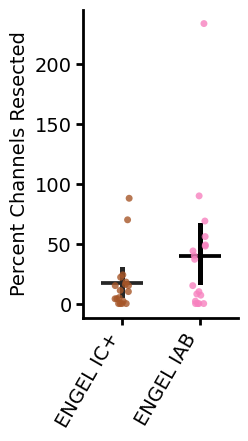

In [26]:
_,ax = plt.subplots(figsize=(2,4))
num_rs_df = resected_chs_wmask.groupby(['rid'])[['outcome','resected','num_ch']].agg(dict(outcome='mean',resected='sum',num_ch='mean')).reset_index()
# num_rs_df['resected'] = num_rs_df['resected']/num_rs_df['num_ch']
sns.stripplot(num_rs_df,
              x='outcome',
              y='resected',
              hue='outcome',
              palette=sns.color_palette('Set1')[6:8],
              legend=False,alpha=0.8)
sns.pointplot(num_rs_df,
              x='outcome',
              y='resected',
            #   order=[0,1],
            #   hue_order=[0,1],
              hue='outcome',
              estimator='mean',
              markers='_',
              markersize=30,
            #   palette='rocket',
              palette='dark:black',
              legend=False)
plt.xticks([0,1],['ENGEL IC+','ENGEL IAB'],rotation=60,ha='right')
print(get_nparam_stats(num_rs_df,'outcome',1,0,'resected'))
sns.despine()
plt.xlabel('')
plt.ylabel('Percent Channels Resected')

In [27]:
pt_resected_chs_wmask = resected_chs_wmask.groupby(['rid','label'])[['outcome','latency','rapid','resected','num_ch','roiNum','n_rois']].mean().reset_index()
pt_resected_chs_wmask['Tissue'] = pt_resected_chs_wmask['resected'].apply(lambda x: ['Spared','Resected'][int(x)])

In [28]:
pt_resected_chs_wmask.rid.nunique()

36

In [29]:
resected_rs_wmask = resected_chs_wmask.groupby(['rid','onset','roiNum']).aggregate({'outcome':'max',
                                                                                    # 'latency':lambda x: np.percentile(x,25),
                                                                                    'latency':'min',
                                                                                    'resected': 'mean','rapid':'max','num_ch':'mean','n_rois':'mean',
                                                                                    'num_ch':'mean'}).reset_index()
resected_rs_wmask['resected'] = resected_rs_wmask['resected']>0
# resected_rs_wmask = resected_chs_wmask 
resected_rs_wmask['Tissue'] = resected_rs_wmask['resected'].apply(lambda x: ['Spared','Resected'][int(x)])

In [30]:
resected_rs_wmask.onset.nunique()

283

#### Plotting interlude

In [31]:
all_rs_img = nib.load('/Applications/freesurfer/7.4.1/subjects/cvs_avg35_inMNI152/mri/aparc+aseg.mgz')
og_affine = all_rs_img.affine
all_rs_mask = all_rs_img.get_fdata()
plot_subset = resected_rs_wmask[resected_rs_wmask.rid==51] # 51
resected_rs = plot_subset[plot_subset.resected].roiNum.unique()
spared_rs = plot_subset[~plot_subset.resected].roiNum.unique()
resected_rs_mask = np.isin(all_rs_mask,resected_rs)
resected_rs_img = nib.Nifti1Image(resected_rs_mask.astype(float),og_affine)
nib.save(resected_rs_img,ospj(prodatapath,'resected_rs.mgz'))
spared_rs_mask = np.isin(all_rs_mask,spared_rs)
spared_rs_img = nib.Nifti1Image(spared_rs_mask.astype(float),og_affine)
nib.save(spared_rs_img,ospj(prodatapath,'spared_rs.mgz'))
null_rs_mask = all_rs_mask.copy()
null_rs_mask[spared_rs_mask]=False
null_rs_mask[resected_rs_mask]=False
null_rs_img = nib.Nifti1Image(null_rs_mask.astype(float),og_affine)
nib.save(null_rs_img,ospj(prodatapath,'null_rs.mgz'))

print(resected_rs)

[  53.   54. 2009. 2033.]


In [32]:
plot_electrodes = resected_chs_wmask[(resected_chs_wmask.onset==445516.0)].sort_values('label').reset_index(drop=True) ## VISUALIZATION
# plot_electrodes = resected_chs_wmask[(resected_chs_wmask.onset== 178818.12)].sort_values('label').reset_index(drop=True)
plot_electrodes['Radius']=3
plot_electrodes['Label'] = plot_electrodes['label']
plot_electrodes[['MNI152_x','MNI152_y','MNI152_z']] = nib.affines.apply_affine(og_affine,plot_electrodes[['vox_x','vox_y','vox_z']].to_numpy())
plot_electrodes[['T1R','T1A','T1S']] = plot_electrodes[['mm_x','mm_y','mm_z']]
plot_electrodes.reset_index(names='Electrode',inplace=True)
plot_electrodes['Electrode'] += 1
plot_cols = ['Electrode','MNI152_x','MNI152_y','MNI152_z','T1R','T1A','T1S','Label','Radius','latency']
plot_table = plot_electrodes[plot_cols]
plot_table.to_csv(ospj(metapath,'rave_electrodes.csv'),index=False)

In [56]:
plot_electrodes = pd.read_csv(ospj(prodatapath,'electrode_localizations','sub-RID0861.csv'))
plot_electrodes = plot_electrodes[~plot_electrodes['roi'].isin(['outside-brain'])]
plot_electrodes['Label'] = plot_electrodes['labels']
plot_electrodes['Radius'] = 2
plot_electrodes[['MNI152_x','MNI152_y','MNI152_z']] = nib.affines.apply_affine(og_affine,plot_electrodes[['vox_x','vox_y','vox_z']].to_numpy())
plot_electrodes[['T1R','T1A','T1S']] = plot_electrodes[['mm_x','mm_y','mm_z']]
plot_electrodes.reset_index(names='Electrode',inplace=True)
plot_electrodes['Electrode'] += 1
plot_cols = ['Electrode','MNI152_x','MNI152_y','MNI152_z','T1R','T1A','T1S','Label','Radius']
plot_table = plot_electrodes[plot_cols]
plot_table.to_csv(ospj(metapath,'HUP238_rave_electrodes.csv'),index=False)

In [33]:
# seizure_data = pd.read_pickle(ospj(prodatapath,'HUP094','seizure-445516.0_fs-256_prebuff-120_postbuff120.pkl'))
# # seizure_data = pd.read_pickle(ospj(prodatapath,'HUP208','seizure-178818.12_fs-256_prebuff-120_postbuff120.pkl'))
# onset_idx = 220
# offset_idx = len(seizure_data)-240
# seizure_data.columns = [x.split('-')[0] for x in seizure_data.columns]
# seizure_crop  = seizure_data.iloc[onset_idx:offset_idx,:]
# seizure_crop.loc[:,['Time']] = np.arange(0,len(seizure_crop))*0.5
# seizure_long = seizure_crop.melt(id_vars='Time',value_name='NDD',var_name='Label')
# rave_seizure = pd.merge(plot_table[['Electrode','Label']],seizure_long,on='Label')
# rave_seizure.drop('Label',axis=1).to_csv(ospj(metapath,'rave_seizure.csv'),index=False)

#### Resume outcomes

(np.float64(0.8615201686829932), np.float64(156.0), np.float64(0.48148148148148145))


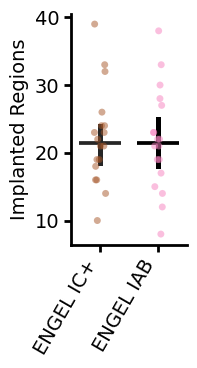

In [34]:
_,ax = plt.subplots(figsize=(1.5,3))
num_rs_df = resected_rs_wmask.groupby(['rid'])[['n_rois','outcome','num_ch']].mean().reset_index()
sns.stripplot(num_rs_df,
              x='outcome',
              y='n_rois',
              hue='outcome',
              palette=sns.color_palette('Set1')[6:8],
              legend=False,
              alpha=0.5)
sns.pointplot(num_rs_df,
              x='outcome',
              y='n_rois',
              hue='outcome',
              estimator='median',
              markers='_',
              markersize=30,
            #   palette='rocket',
              palette='dark:black',
              legend=False)
plt.xticks([0,1],['ENGEL IC+','ENGEL IAB'],rotation=60,ha='right')
print(get_nparam_stats(num_rs_df,'outcome',1,0,'n_rois'))
sns.despine()
plt.xlabel('')
plt.ylabel('Implanted Regions')
plt.savefig(ospj(figpath,'outcome_regions.pdf'),bbox_inches='tight')

#### Analyses

##### Has Sz spread outside resection mask? (r)

In [35]:
resected = False
all_ds = []
all_ps = []
all_us = []
all_cis = []  # To store CIs for difference in Cohen's d between spared and all
ts = range(1, 61, 1)
line_plotting_list = []
box_plotting_list = []

def boot_seizure_level_cohend_diff(plot_df, all_df, n_bootstrap=100, ci=0.95, random_state=None):
    """
    Bootstrap seizures (onset), compute Cohen's d for spared (resected==False) and all, 
    returns: (diff_estimate, lower, upper)
    """
    rng = np.random.default_rng(random_state)
    seized_ids = plot_df['onset'].unique()
    all_ids = all_df['onset'].unique()
    ds_spared = []
    ds_all = []
    # For each bootstrap
    for _ in range(n_bootstrap):
        # Resample seizure onsets for both, so keep consistent length with replacement
        boot_seized_ids = rng.choice(seized_ids, size=len(seized_ids), replace=True)
        boot_all_ids = rng.choice(all_ids, size=len(all_ids), replace=True)
        p_boot = plot_df[plot_df['onset'].isin(boot_seized_ids)]
        a_boot = all_df[all_df['onset'].isin(boot_all_ids)]
        # For "spared": resected==False
        ds_spared.append(cohens_d(
            p_boot[(p_boot.outcome == 0) & (p_boot.resected == False)].seizing,
            p_boot[(p_boot.outcome == 1) & (p_boot.resected == False)].seizing
        ))
        # For "all":
        ds_all.append(cohens_d(
            a_boot[a_boot.outcome == 0].seizing,
            a_boot[a_boot.outcome == 1].seizing
        ))
    # Actual Cohen's d on original full data
    cd_spared = cohens_d(
        plot_df[(plot_df.outcome == 0) & (plot_df.resected == False)].seizing,
        plot_df[(plot_df.outcome == 1) & (plot_df.resected == False)].seizing
    )
    cd_all = cohens_d(
        all_df[all_df.outcome == 0].seizing,
        all_df[all_df.outcome == 1].seizing
    )
    diffs = np.array(ds_spared) - np.array(ds_all)
    point_est = np.abs(cd_spared) - np.abs(cd_all)
    lower = np.percentile(diffs, (1 - ci) / 2 * 100)
    upper = np.percentile(diffs, (1 + ci) / 2 * 100)
    return point_est, lower, upper

for t in ts:
    resected_rs_wmask['rapid'] = resected_rs_wmask['latency'] < t
    resected_rs_wmask['seizing'] = resected_rs_wmask['rapid']
    plot_df = resected_rs_wmask.groupby(['rid', 'onset', 'Tissue'])[['seizing', 'outcome', 'resected']].aggregate({"seizing": "sum", "outcome": 'mean', 'resected': 'mean'}).reset_index()
    plot_df['time'] = [t] * len(plot_df)
    plot_df['Outcome'] = plot_df['outcome'].apply(lambda x: np.array(['ENGEL IC+', 'ENGEL IAB'])[int(x)])
    line_plotting_list.append(plot_df)
    box_plotting_list.append(plot_df)
    d_list = []
    p_list = []
    u_list = []
    for i, r in enumerate([True, False]):
        d_list.append(cohens_d(plot_df[(plot_df.outcome == 0) & (plot_df.resected == r)].seizing,
                               plot_df[(plot_df.outcome == 1) & (plot_df.resected == r)].seizing))
        u, p = sc.stats.mannwhitneyu(plot_df[(plot_df.outcome == 0) & (plot_df.resected == r)].seizing,
                                     plot_df[(plot_df.outcome == 1) & (plot_df.resected == r)].seizing,
                                     alternative='greater'
                                     )
        p_list.append(p)
        u_list.append(u / (len(plot_df[(plot_df.outcome == 0) & (plot_df.resected == r)]) * len(plot_df[(plot_df.outcome == 1) & (plot_df.resected == r)])))
    all_df = resected_rs_wmask.groupby(['rid', 'onset'])[['seizing', 'outcome']].aggregate({"seizing": "sum", "outcome": 'mean'}).reset_index()
    all_df['Tissue'] = 'All'
    all_df['time'] = [t] * len(all_df)
    all_df['Outcome'] = all_df['outcome'].apply(lambda x: np.array(['ENGEL IC+', 'ENGEL IAB'])[int(x)])
    box_plotting_list.append(all_df)
    d_list.append(cohens_d(all_df[all_df.outcome == 0].seizing,
                           all_df[all_df.outcome == 1].seizing))
    u, p = sc.stats.mannwhitneyu(all_df[(all_df.outcome == 0)].seizing,
                                 all_df[all_df.outcome == 1].seizing,
                                 alternative='greater'
                                 )
    p_list.append(p)
    u_list.append(u / (len(all_df[(all_df.outcome == 0)]) * len(all_df[(all_df.outcome == 1)])))
    # --- Bootstrap at the SEIZURE LEVEL (onset), CIs on difference in abs(Cohen's d) ---
    point_est, lower, upper = boot_seizure_level_cohend_diff(plot_df, all_df, n_bootstrap=100, ci=0.95, random_state=None)
    all_cis.append([point_est, lower, upper])
    all_ds.append(d_list)
    all_ps.append(p_list)
    all_us.append(u_list)

all_ds = np.abs(np.array(all_ds))
all_ps = np.abs(np.array(all_ps))
all_us = np.abs(np.array(all_us))
all_cis = np.array(all_cis)

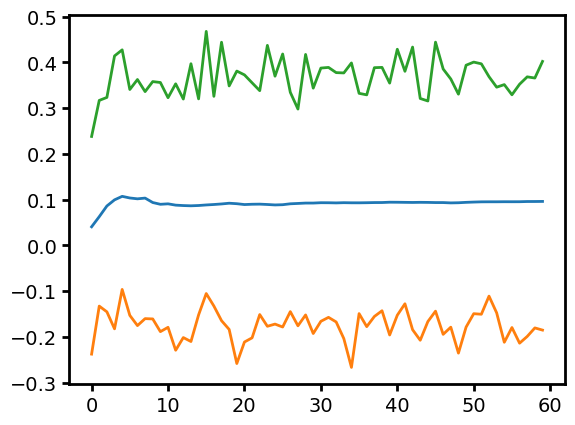

In [36]:
plt.plot(all_cis)

Cohen's d at t=5s (Spared): 0.8088074844300941
Cohen's d at t=5s (Resected): 0.30938563890063514
Cohen's d at t=5s (All): 0.7015263567168525
Cohen's d at t=1s (Spared): 0.5636837587584675
Cohen's d at t=1s (Resected): 0.024938949847822304
Cohen's d at t=1s (All): 0.5229902553318813


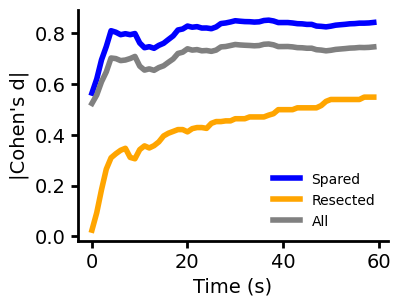

In [ ]:
_,ax = plt.subplots(figsize=(4,3))
# ax.axvline(20,linewidth=2,linestyle='--',c='black')
all_us = np.abs(all_us-.5)
plt.plot(all_ds[:,1],c='blue',linewidth=4,label='Spared')
plt.plot(np.abs(all_ds[:,0]),c='orange',linewidth=4,label='Resected')
plt.plot(all_ds[:,2],c='grey',linewidth=4,label='All')
plt.legend()
plt.ylabel('|Cohen\'s d|')
plt.xlabel('Time (s)')
sns.despine()
plt.savefig(ospj(figpath,'cohend_outcome_resection.pdf'),bbox_inches='tight')
# Print the Cohen's d of each trace at t=5 (i.e., index 1 since t likely starts at 0 or 1)
time_idx = 4  # since times go from 1,6,11..., t=5 is likely the second entry if 5s intervals
print("Cohen's d at t=5s (Spared):", all_ds[time_idx,1])
print("Cohen's d at t=5s (Resected):", all_ds[time_idx,0])
print("Cohen's d at t=5s (All):", all_ds[time_idx,2])

time_idx = 0  # since times go from 1,6,11..., t=5 is likely the second entry if 5s intervals
print("Cohen's d at t=1s (Spared):", all_ds[time_idx,1])
print("Cohen's d at t=1s (Resected):", all_ds[time_idx,0])
print("Cohen's d at t=1s (All):", all_ds[time_idx,2])

In [38]:
def find_knee(x, y):
    # First and last points
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    # Line vector and normalize
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    # Compute distances from the line
    vec_from_p1 = np.array([x, y]).T - p1
    projection = np.dot(vec_from_p1, line_vec_norm)
    proj_vec = np.outer(projection, line_vec_norm)
    dist_vec = vec_from_p1 - proj_vec
    distances = np.linalg.norm(dist_vec, axis=1)

    # Knee point
    knee_idx = np.argmax(distances)

    return knee_idx
find_knee(range(1,61,1),all_ds[:,1])

np.int64(4)

5
38
0.8503807346687579
1


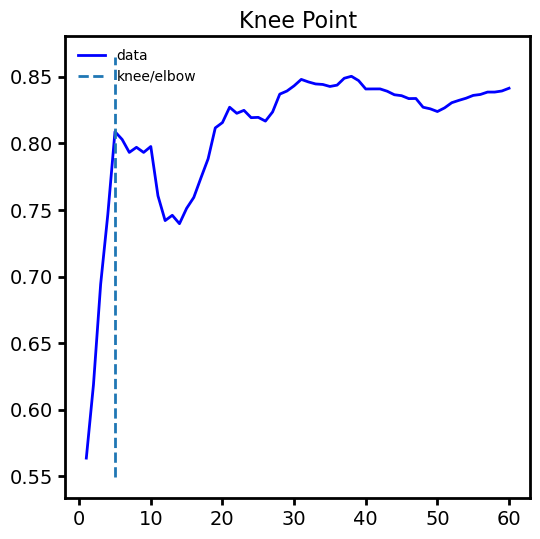

In [39]:
kl = KneeLocator(range(1,61,1),all_ds[:,1],curve='concave')
kl.plot_knee()
print(kl.knee)
print(np.argmax(all_ds[:,1])+1)
print(all_ds[np.argmax(all_ds[:,1]),1])
print(np.argwhere(all_ds[:,1]>0.6)[0][0])


Mixed Effects Model for spread regions at t==1s
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  seizing   
No. Observations:    489      Method:              REML      
No. Groups:          36       Scale:               8.4029    
Min. group size:     2        Log-Likelihood:      -1234.9874
Max. group size:     76       Converged:           Yes       
Mean group size:     13.6                                    
-------------------------------------------------------------
                     Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept            2.003    0.399 5.019 0.000  1.221  2.785
Outcome[T.ENGEL IC+] 0.770    0.578 1.333 0.183 -0.362  1.903
Group Var            1.940    0.271                          

T-test between Outcome groups (ENGEL IC+ vs ENGEL IAB) at t=1s:
t = 4.395, p = 1.36e-05

Mixed Effects Model for spread regions at t==5s
            Mixed L

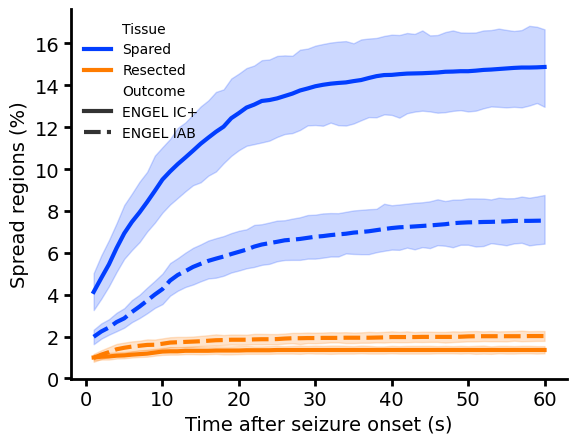

In [47]:
line_plotting_df = pd.concat(line_plotting_list)

# --- Mixed Effects Models at t==0 and t==5 separately ---
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind

for t_val in [1, 5]:
    print(f"\nMixed Effects Model for spread regions at t=={t_val}s")
    subset_df = line_plotting_df[line_plotting_df['time'] == t_val].copy()
    # Ensure 'Outcome' and 'rid' are categorical
    subset_df['Outcome'] = subset_df['Outcome'].astype('category')
    if 'rid' in subset_df.columns:
        subset_df['rid'] = subset_df['rid'].astype('category')
        random_col = 'rid'
    else:
        subset_df['RID'] = subset_df['RID'].astype('category')
        random_col = 'RID'
    # Fit model: seizing ~ Outcome, with random intercept for patient
    md = smf.mixedlm("seizing ~ Outcome", subset_df, groups=subset_df[random_col])
    mdf = md.fit()
    print(mdf.summary())

    # Also: print t-test (not accounting for patient variance)
    # Note: This assumes Outcome is binary/categorical with 2 groups
    # and 'seizing' is the variable of interest
    # Get the unique outcome values for group division
    outcome_levels = subset_df['Outcome'].unique()
    if len(outcome_levels) == 2:
        group1 = subset_df[subset_df['Outcome'] == outcome_levels[0]]['seizing']
        group2 = subset_df[subset_df['Outcome'] == outcome_levels[1]]['seizing']
        t_stat, p_val = ttest_ind(group1, group2, nan_policy='omit')
        print(f"T-test between Outcome groups ({outcome_levels[0]} vs {outcome_levels[1]}) at t={t_val}s:")
        print(f"t = {t_stat:.3f}, p = {p_val:.3g}")
    else:
        print("Could not run t-test: Outcome does not have exactly 2 levels.")

# --- Plotting as before ---
sns.lineplot(line_plotting_df, x='time', y='seizing', hue='Tissue',
             palette='bright',
             style='Outcome', linewidth=3,
             hue_order=['Spared', 'Resected'])
plt.ylabel('Spread regions (%)')
plt.xlabel('Time after seizure onset (s)')
sns.despine()
plt.show()

[None, None]

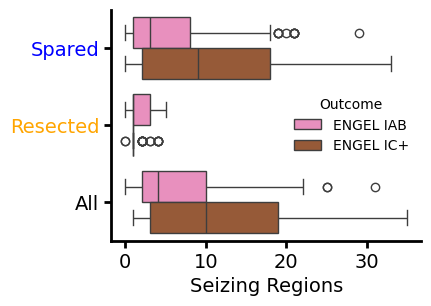

In [346]:
box_plotting_df = pd.concat(box_plotting_list)
_,ax = plt.subplots(figsize=(4,3))

sns.boxplot(box_plotting_df[box_plotting_df.time == 15],
               y='Tissue',x='seizing',
               order=['Spared','Resected','All'],
               hue='Outcome',
               palette=sns.color_palette('Set1')[6:8][::-1],
               dodge=True,
               hue_order=['ENGEL IAB','ENGEL IC+'],
               ax=ax,
               orient='h',
            #    split=True,
            #    inner=None,
            #    gap=.03,
            #    fill=False,
               )
               
plt.xlabel('Seizing Regions')
plt.ylabel('')
sns.despine()
[t.set_color(i) for (i,t) in
zip(['blue','orange'],ax.yaxis.get_ticklabels())]

##### Has the seizure spread outside the resection mask? (percent)

In [169]:
resected=False
all_ds=[]
all_ps = []
all_us = []
ts = range(1,101,1)
line_plotting_list = []
box_plotting_list = []

for t in ts:
    resected_rs_wmask['rapid'] = resected_rs_wmask['latency'] < t
    resected_rs_wmask['seizing'] = resected_rs_wmask['rapid']/resected_rs_wmask['n_rois']*100
    plot_df = resected_rs_wmask.groupby(['rid','onset','Tissue'])[['seizing','outcome','resected']].aggregate({"seizing": "sum", "outcome": 'mean','resected':'mean'}).reset_index()
    plot_df['time'] = [t]*len(plot_df)
    plot_df['Outcome'] = plot_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
    line_plotting_list.append(plot_df)
    box_plotting_list.append(plot_df)
    d_list = []
    p_list = []
    u_list = []
    for i,r in enumerate([True,False]):
        d_list.append(cohens_d(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)].seizing,
                plot_df[(plot_df.outcome==1) & (plot_df.resected == r)].seizing))
        u,p = sc.stats.mannwhitneyu(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)].seizing,
                                    plot_df[(plot_df.outcome==1) & (plot_df.resected == r)].seizing,
                                    alternative='greater'
                                    )
        p_list.append(p)
        u_list.append(u/(len(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)])*len(plot_df[(plot_df.outcome==1) & (plot_df.resected == r)])))

    all_df = resected_rs_wmask.groupby(['rid','onset'])[['seizing','outcome']].aggregate({"seizing": "sum", "outcome": 'mean'}).reset_index()
    all_df['Tissue'] = 'All'
    all_df['time'] = [t]*len(all_df)
    all_df['Outcome'] = all_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
    box_plotting_list.append(all_df)
    d_list.append(cohens_d(all_df[all_df.outcome==0].seizing,
                all_df[all_df.outcome==1].seizing))
    u,p = sc.stats.mannwhitneyu(all_df[(all_df.outcome==0)].seizing,
                                    all_df[all_df.outcome==1].seizing,
                                    alternative='greater'
                                    )
    p_list.append(p)
    u_list.append(u/(len(all_df[(all_df.outcome==0)])*len(all_df[(all_df.outcome==1)])))
    
    all_ds.append(d_list)
    all_ps.append(p_list)
    all_us.append(u_list)

all_ds = np.array(all_ds)
all_ps = np.array(all_ps)
all_us = np.array(all_us)

In [170]:
# resected = False
# all_ds = []
# all_ps = []
# ts = range(1,101,1)
# line_plotting_list = []
# for t in ts:
#     resected_rs_wmask['rapid'] = resected_rs_wmask['latency'] < t
#     resected_rs_wmask['outside_resection'] = resected_rs_wmask['rapid']/resected_rs_wmask['n_rois']*100
#     plot_df = resected_rs_wmask.groupby(['rid','onset','resected'])[['outside_resection','outcome']].aggregate({"outside_resection": "sum", "outcome": 'mean'}).reset_index()
#     plot_df['time'] = [t]*len(plot_df)
#     plot_df['Outcome'] = plot_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
#     line_plotting_list.append(plot_df)
#     _,p = sc.stats.mannwhitneyu(plot_df[(plot_df.outcome==0) & (plot_df.resected == resected)].outside_resection,
#                                     plot_df[plot_df.outcome==1 & (plot_df.resected == resected)].outside_resection,
#                                     alternative='greater')
    
#     d_list = []
#     for i,r in enumerate([True,False]):
#         d_list.append(cohens_d(plot_df[plot_df.outcome==0 & (plot_df.resected == r)].outside_resection,
#                 plot_df[plot_df.outcome==1 & (plot_df.resected == r)].outside_resection))
#     all_ds.append(d_list)
#     all_ps.append(p)
    
# all_ds = np.array(all_ds)

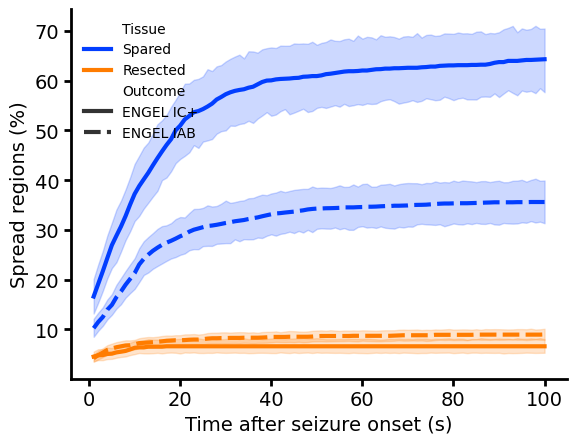

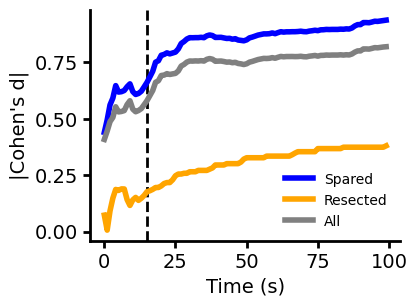

In [171]:
line_plotting_df = pd.concat(line_plotting_list)
sns.lineplot(line_plotting_df,x='time',y='seizing',hue='Tissue',
             palette = 'bright',
             style='Outcome',linewidth=3,
             hue_order=['Spared','Resected'])
plt.ylabel('Spread regions (%)')
plt.xlabel('Time after seizure onset (s)')
sns.despine()
plt.show()

_,ax = plt.subplots(figsize=(4,3))
ax.axvline(15,linewidth=2,linestyle='--',c='black')

plt.plot(all_ds[:,1],c='blue',linewidth=4,label='Spared')
plt.plot(np.abs(all_ds[:,0]),c='orange',linewidth=4,label='Resected')
plt.plot(all_ds[:,2],c='grey',linewidth=4,label='All')
plt.legend()
plt.ylabel('|Cohen\'s d|')
plt.xlabel('Time (s)')
sns.despine()

In [172]:
sns.boxplot(line_plotting_df[line_plotting_df.time == 10],x='resected',y='outside_resection',hue='Outcome',palette='rocket')

ValueError: Could not interpret value `outside_resection` for `y`. An entry with this name does not appear in `data`.

##### Has sz spread outside resection mask? (pt)

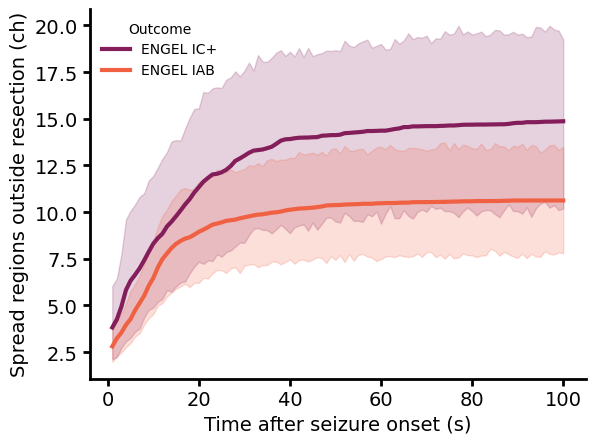

In [173]:
all_ds = []
all_ps = []
ts = range(1,101,1)
line_plotting_list = []
for t in ts:
    resected_rs_wmask['rapid'] = resected_rs_wmask['latency'] < t
    resected_rs_wmask['outside_resection'] = resected_rs_wmask['rapid']#/resected_rs_wmask['num_rs']*100
    plot_df = resected_rs_wmask[resected_rs_wmask.resected == False].groupby(['rid','onset'])[['outside_resection','outcome']].aggregate({"outside_resection": "sum", "outcome": 'mean'}).reset_index()
    pt_plot_df = plot_df.groupby('rid')[['outside_resection','outcome']].aggregate({"outside_resection": "mean", "outcome": 'mean'}).reset_index()
    pt_plot_df['time'] = [t]*len(pt_plot_df)
    pt_plot_df['Outcome'] = pt_plot_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
    line_plotting_list.append(pt_plot_df)
    _,p = sc.stats.mannwhitneyu(pt_plot_df[pt_plot_df.outcome==0].outside_resection,
                                    pt_plot_df[pt_plot_df.outcome==1].outside_resection)
    d = cohens_d(pt_plot_df[pt_plot_df.outcome==0].outside_resection,
                                pt_plot_df[pt_plot_df.outcome==1].outside_resection)
    all_ds.append(d)
    all_ps.append(p)
line_plotting_df = pd.concat(line_plotting_list)
sns.lineplot(line_plotting_df,x='time',y='outside_resection',hue='Outcome',palette = 'rocket',linewidth=3)
plt.ylabel('Spread regions outside resection (ch)')
plt.xlabel('Time after seizure onset (s)')
sns.despine()
plt.show()
# plt.plot(all_ds,c=sns.color_palette('rocket_r')[3],linewidth=4)
# max_d_idx = np.where(np.array(all_ps) < 0.05)[0][0]
# max_t = ts[max_d_idx]
# plt.axvline(max_t,c='black',linestyle='--')
# plt.text(max_t+5,all_ds[max_t],f'p = {all_ps[max_d_idx]: .4f}',{'weight':'bold','size':12,'style':'italic'})
# plt.xlabel('Time since seizure onset (s)')
# plt.ylabel('Cohen\'s d')
# plt.title('Difference in extra-resection spread by outcome')
# sns.despine()
# plt.show()
# print(max_t)

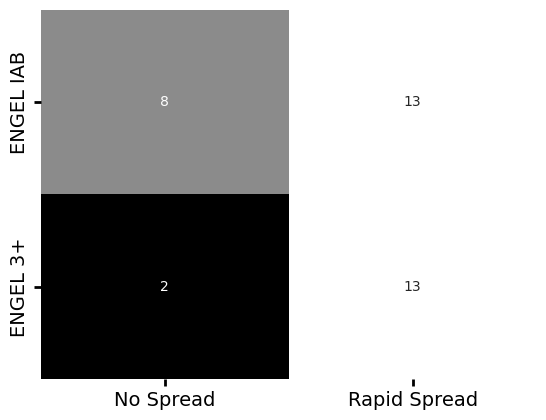

In [179]:
# Load the dataset
data = line_plotting_df

# Initialize results dictionary
results = []

# Iterate through each time point
time_points = data['time'].unique()
for time in time_points:
    for n in [2]:#range(1,16):
        
        subset = data[data['time'] == time]
        
        true_labels = subset['outcome'] == 0
        predictions = subset['outside_resection'] > n

        # Calculate confusion matrix
        tn, fp, fn, tp = confusion_matrix(true_labels, predictions).ravel()
        
        # Calculate sensitivity and specificity
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp/(tp+fp) if (tp+fp) > 0 else 0
        npv = tn/(tn+fn) if (tn+fn) > 0 else 0
        # Calculate AUC
        auc = roc_auc_score(true_labels, subset['outside_resection'])
        
        results.append({'time': time, 'sensitivity': sensitivity, 'specificity': specificity, 'ppv':ppv,'npv':npv,'nregions': n})#, 'auc': auc})
        if time  == 10:
            sns.heatmap([[tn,fp],[fn,tp]],annot=True,cbar=False,cmap='gray')
            plt.yticks([0.5,1.5],['ENGEL IAB','ENGEL 3+',])
            plt.xticks([0.5,1.5], ['No Spread','Rapid Spread',])
            plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_long = results_df.melt(id_vars=['time','nregions'], var_name='metric', value_name='value')

(0.0, 20.0)

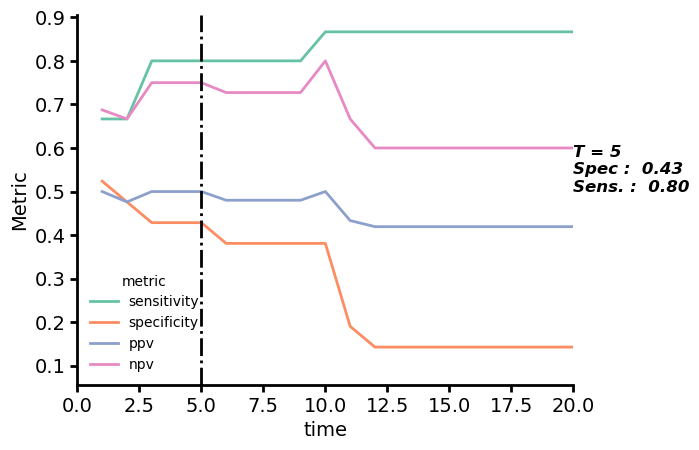

In [180]:
# sns.lineplot(results_long[results_long['metric'] == 'specificity'],x='time',y='value',hue='nregions',palette='rocket')
# sns.lineplot(results_long[results_long['metric'] == 'sensitivity'],x='time',y='value',hue='nregions',palette='viridis')
sns.lineplot(results_long,x='time',y='value',hue='metric',palette='Set2')
T = 5
plt.axvline(T,c='black',linestyle='-.')
plt.text(20,.5,
         f'T = {T}\nSpec : {results_long.value[(results_long.metric == "specificity") & (results_long.time == T)].item() : .2f} \nSens. : {results_long.value[(results_long.metric == "sensitivity") & (results_long.time == T)].item() : .2f}',
         {'weight':'bold','size':12,'style':'italic'})
sns.despine()
plt.ylabel('Metric')
plt.xlim([0,20])

##### Proportion of rapid spread channels outside the resection mask

In [201]:
pt_resected_rs_wmask.groupby(['outcome','resected'])['rapid'].mean().reset_index()

NameError: name 'pt_resected_rs_wmask' is not defined

In [176]:
plot_df = pt_resected_rs_wmask
sns.barplot(plot_df,x='outcome',y='resected',hue='rapid',palette='flare_r')
plt.ylabel('Resected Channels (%)')
plt.xlabel('Outcome')
plt.xticks([0,1],['ENGEL IC+','ENGEL IAB'])
stats_mask1 = (plot_df['outcome'] == 0) & (plot_df['rapid'])
stats_mask2 = (plot_df['outcome'] == 1) & (plot_df['rapid'])
_,p = sc.stats.mannwhitneyu(plot_df[stats_mask1].resected,plot_df[stats_mask2].resected)
plt.title(f"Percent of rapid spread (<10 s) channels resected")
print(p)
sns.despine()

NameError: name 'pt_resected_rs_wmask' is not defined

nan
-0.13281054106062576


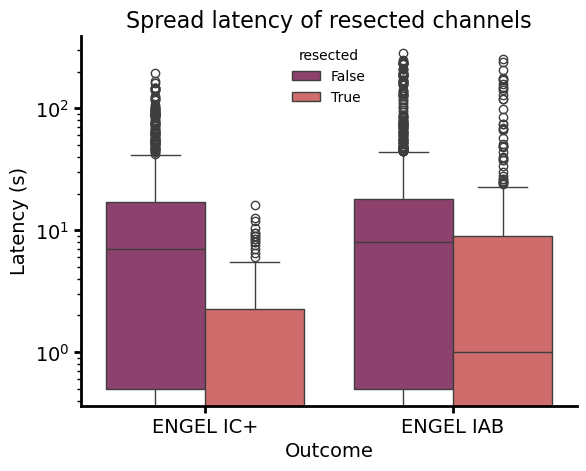

In [177]:
plot_df = resected_rs_wmask
sns.boxplot(plot_df,x='outcome',y='latency',hue='resected',palette='flare_r')
plt.ylabel('Latency (s)')
plt.xlabel('Outcome')
plt.xticks([0,1],['ENGEL IC+','ENGEL IAB'])
# stats_mask1 = (plot_df['outcome'] == 0) & (~plot_df['resected'])
# stats_mask2 = (plot_df['outcome'] == 1) & (~plot_df['resected'])
stats_mask1 = (plot_df['outcome'] == 0)
stats_mask2 = (plot_df['outcome'] == 1)
_,p = sc.stats.mannwhitneyu(plot_df[stats_mask1].latency,plot_df[stats_mask2].latency)
d = cohens_d(plot_df[stats_mask1].latency,plot_df[stats_mask2].latency)
plt.title(f"Spread latency of resected channels")
print(p)
print(d)
plt.yscale('log')
sns.despine()

<Axes: xlabel='outcome', ylabel='resected'>

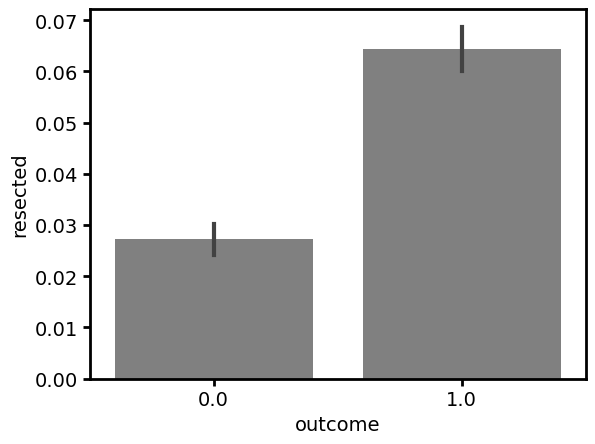

In [178]:
sns.barplot(resected_chs_wmask,y='resected',x='outcome',color='grey')